# Generative Adversarial Networks (GANs)


**Author:** *Corneliu Catlabuga*

**Group:** *IS-251M*

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from keras import layers

In [3]:
# Load MNIST — 60,000 grayscale images of handwritten digits (28×28)
(X_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

# Add channel dimension: (60000, 28, 28) → (60000, 28, 28, 1)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')

# Normalize pixel values from [0, 255] to [-1, 1]
X_train = (X_train - 127.5) / 127.5

# Create batched TensorFlow dataset
BUFFER_SIZE = 60000
BATCH_SIZE = 256

X_train = tf.data.Dataset.from_tensor_slices(X_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

W0000 00:00:1779015684.581467   16419 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779015684.583625   16419 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779015684.687204   16419 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5220 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [4]:
def make_generator():
    model = tf.keras.Sequential([
        # Project and reshape noise into spatial feature map
        layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),

        # Upsample: 7×7 → 7×7
        layers.Conv2DTranspose(128, (5,5), strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Upsample: 7×7 → 14×14
        layers.Conv2DTranspose(64, (5,5), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Upsample: 14×14 → 28×28, single channel output
        layers.Conv2DTranspose(1, (5,5), strides=2, padding='same', use_bias=False, activation='tanh'),
    ])
    return model

generator = make_generator()
generator.summary()

/home/muffindud/Documents/RNIP/lab5/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

I0000 00:00:1779015690.271494   16419 cuda_dnn.cc:461] Loaded cuDNN version 92200


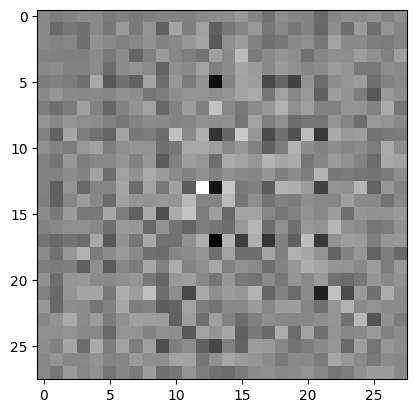

In [5]:
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)
plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [6]:
def make_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5,5), strides=2, padding='same', input_shape=(28,28,1)),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5,5), strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1),  # Raw logit — no sigmoid here
    ])
    return model

discriminator = make_discriminator()
discriminator.summary()

/home/muffindud/Documents/RNIP/lab5/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
decision = discriminator(generated_image, training=False)
print(decision)  # Raw logit, ~0 = uncertain

tf.Tensor([[0.00378652]], shape=(1, 1), dtype=float32)


In [8]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator wins when discriminator predicts 1 on fake images
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer     = tf.keras.optimizers.Adam(learning_rate=1e-5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

E0000 00:00:1779015692.241149   16419 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 1 complete


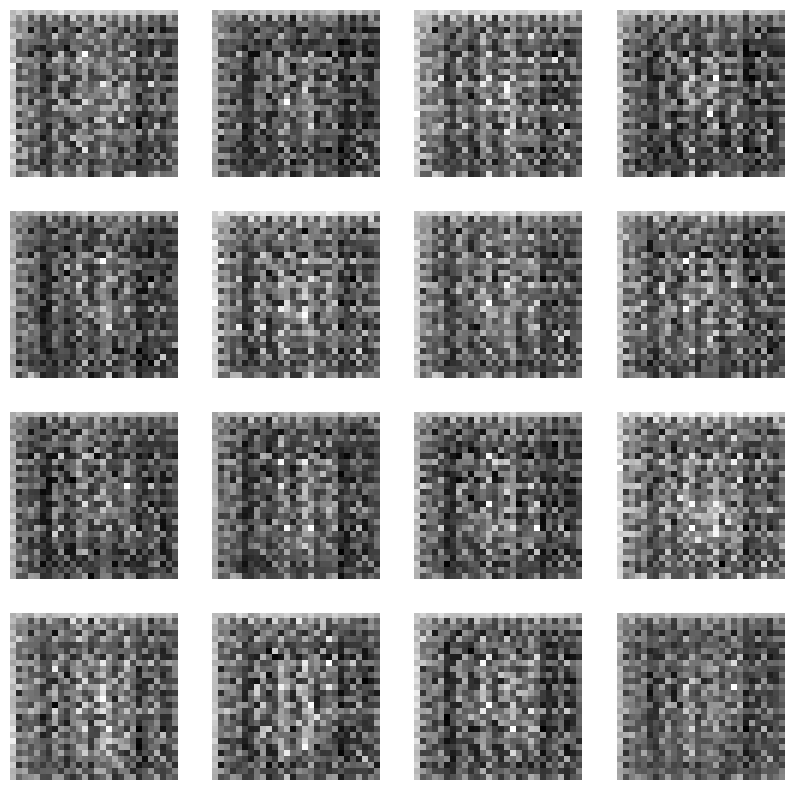

Epoch 2 complete


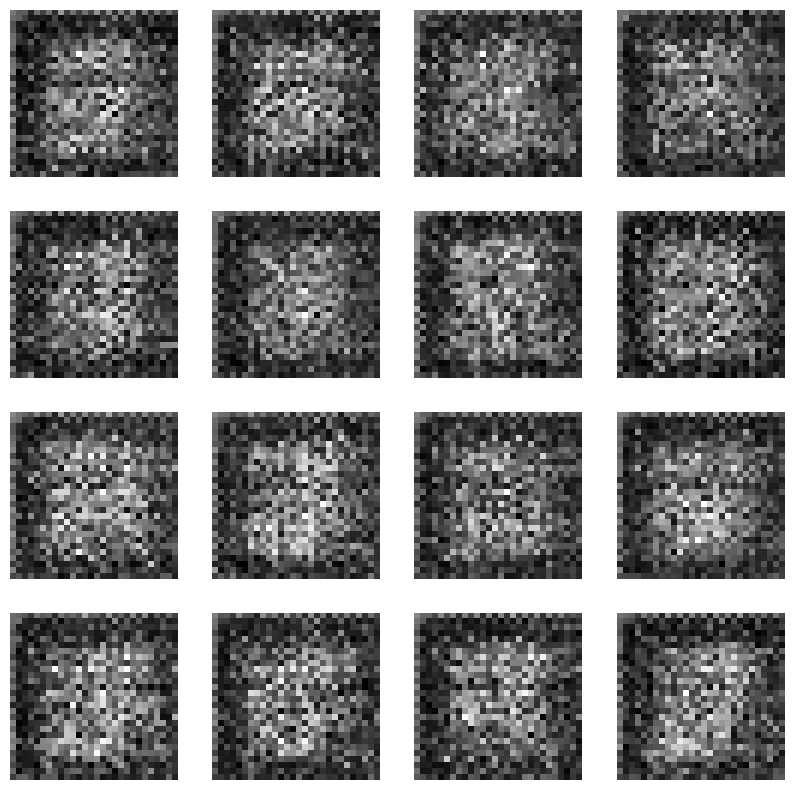

Epoch 3 complete


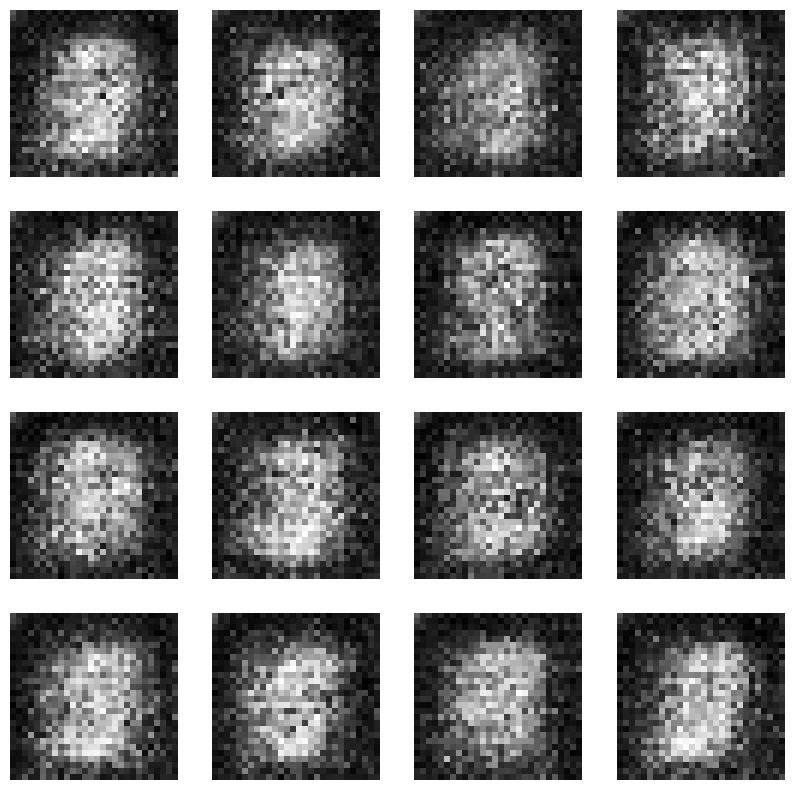

Epoch 4 complete


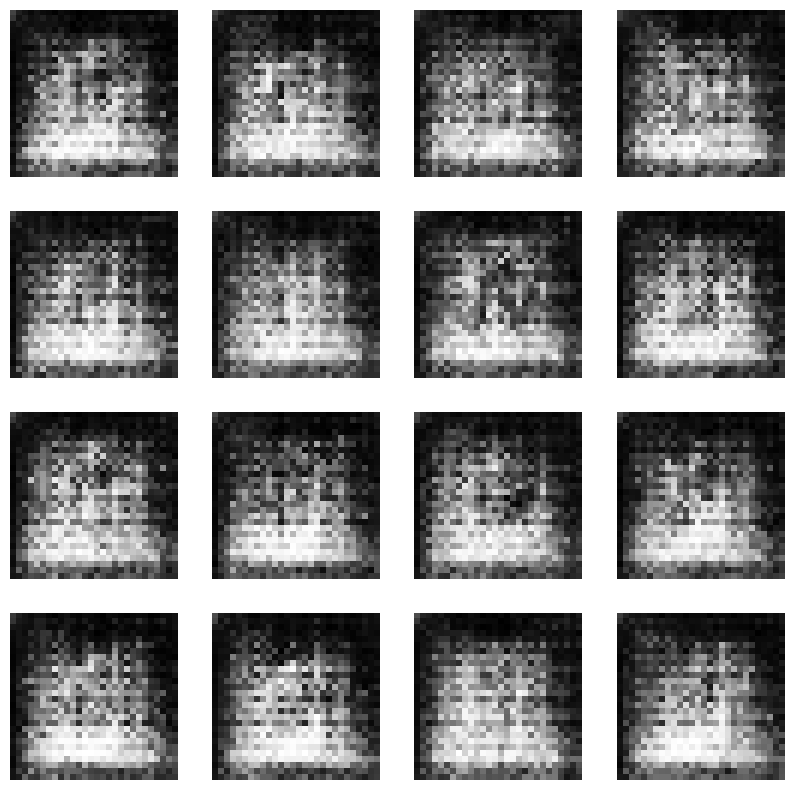

Epoch 5 complete


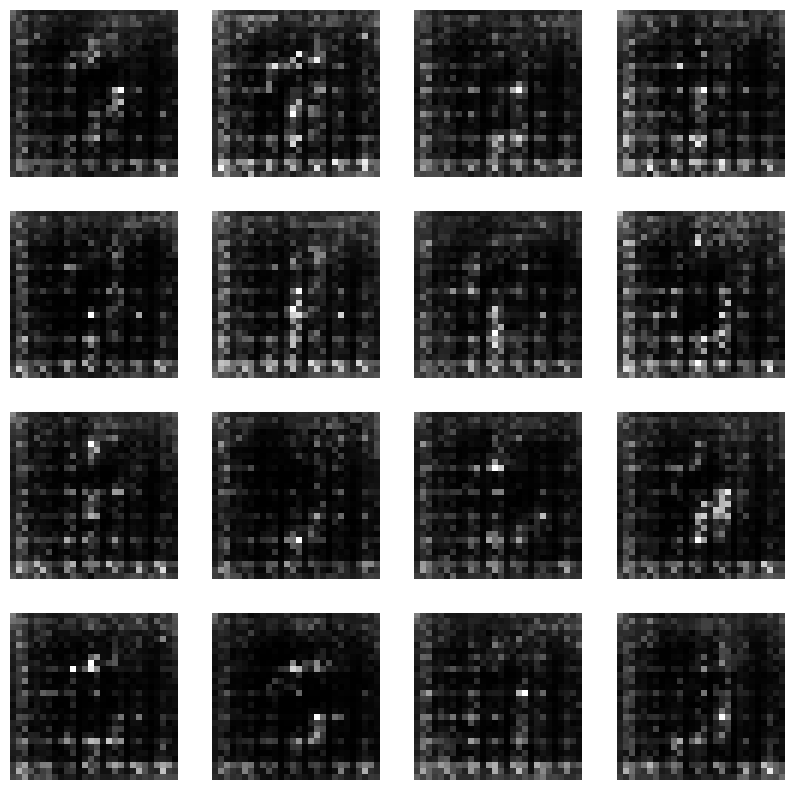

Epoch 6 complete


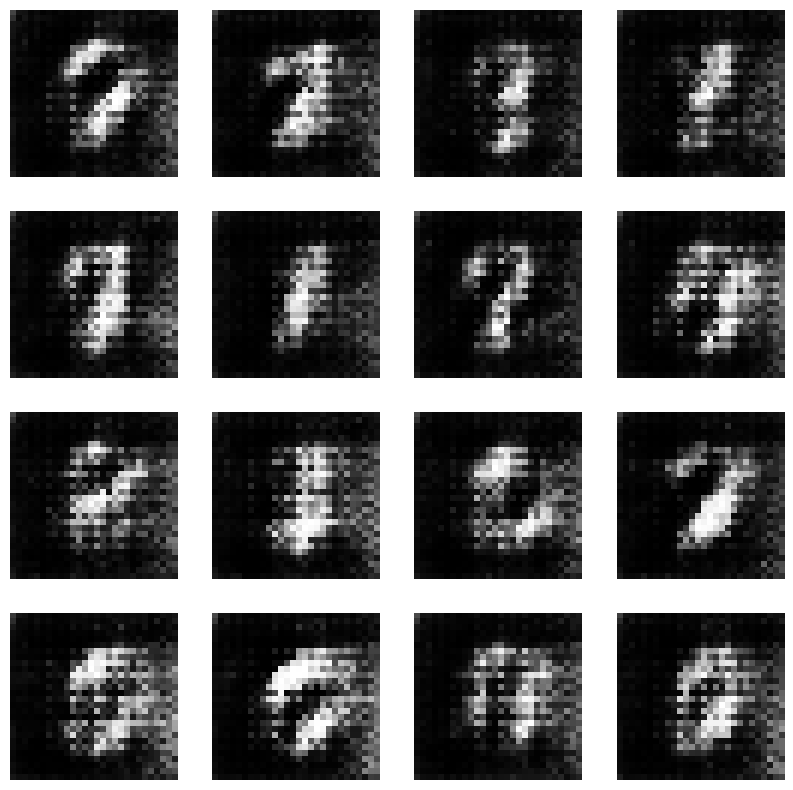

Epoch 7 complete


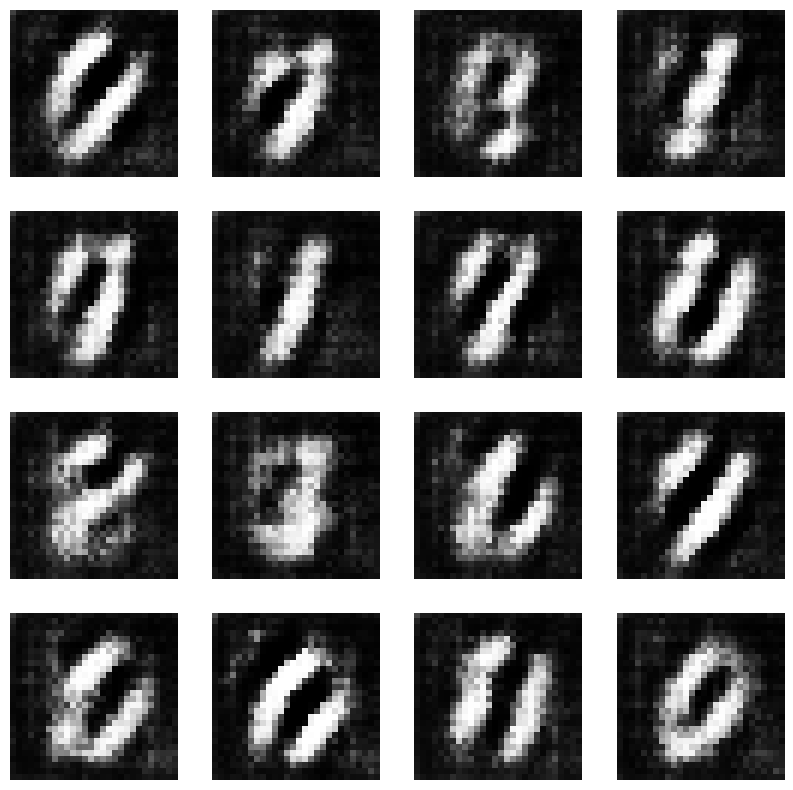

Epoch 8 complete


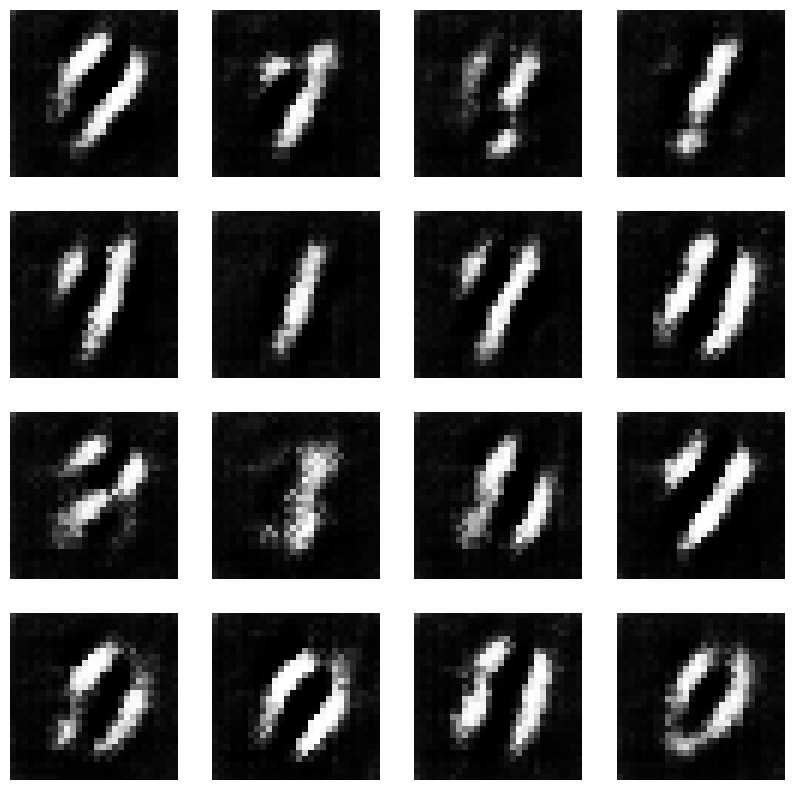

Epoch 9 complete


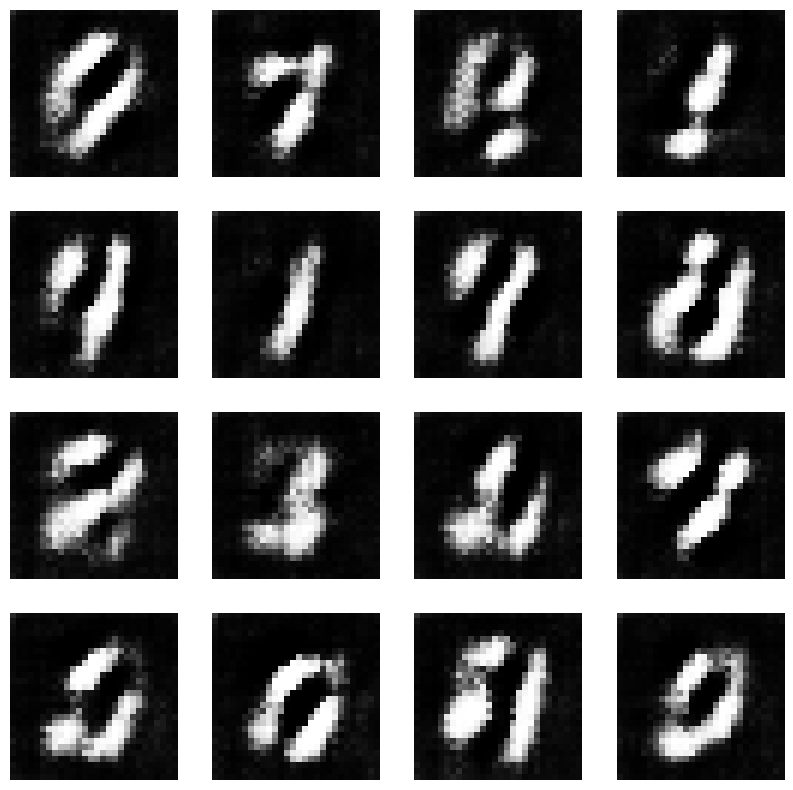

Epoch 10 complete


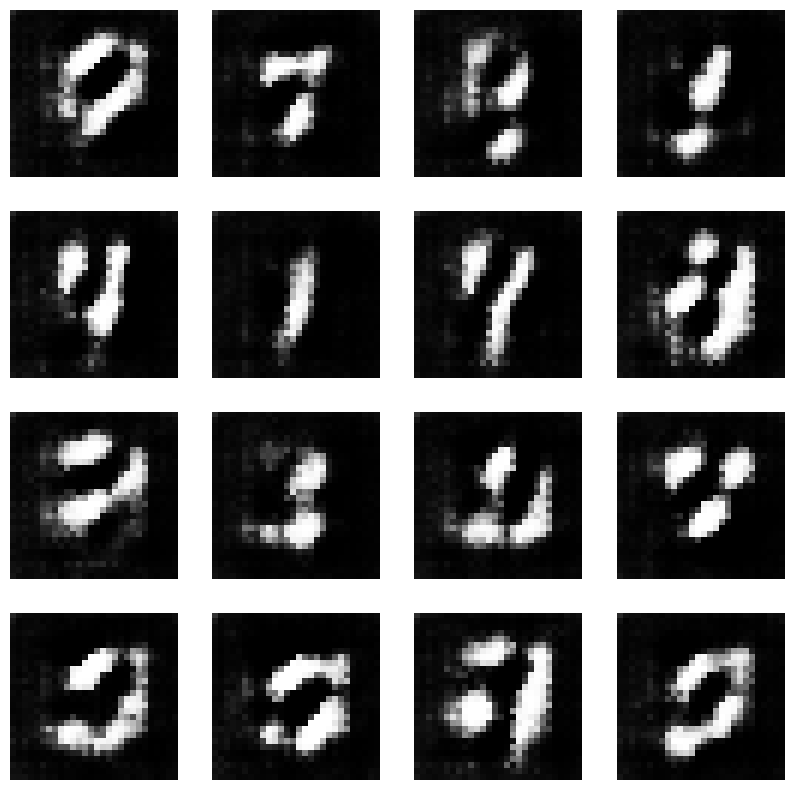

Epoch 11 complete


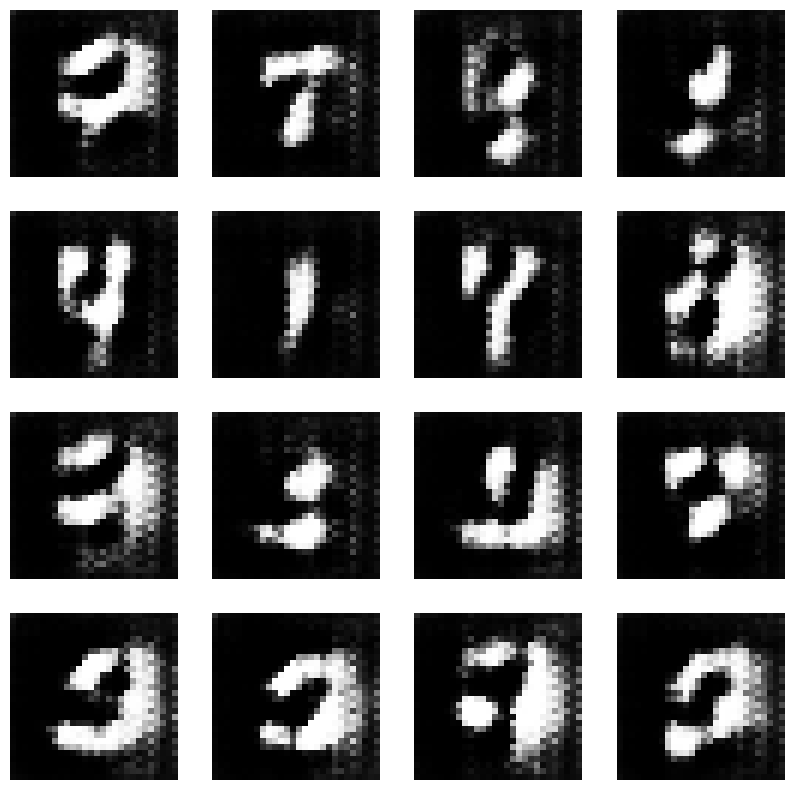

Epoch 12 complete


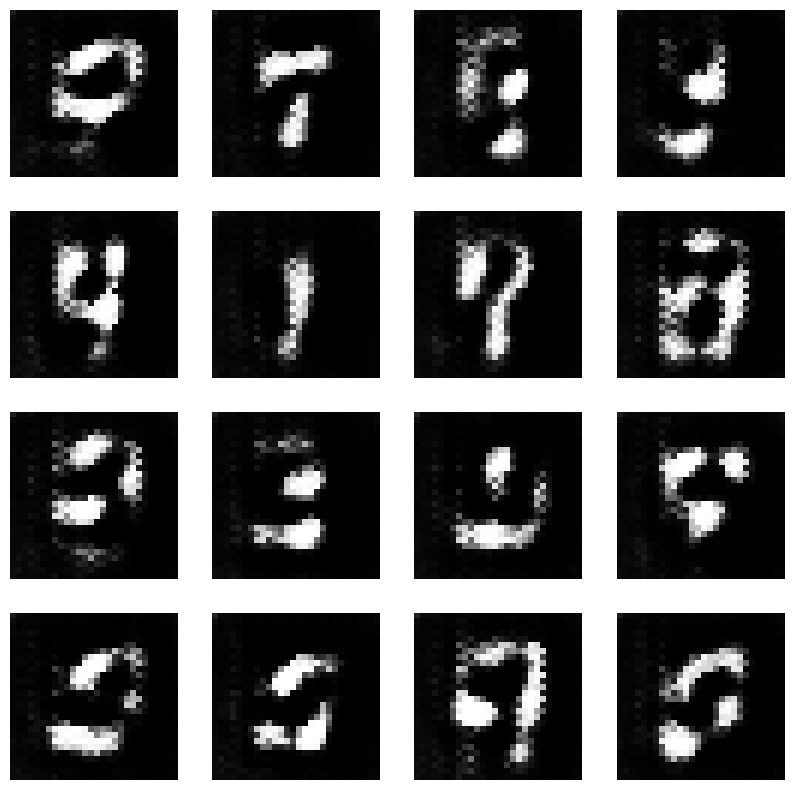

Epoch 13 complete


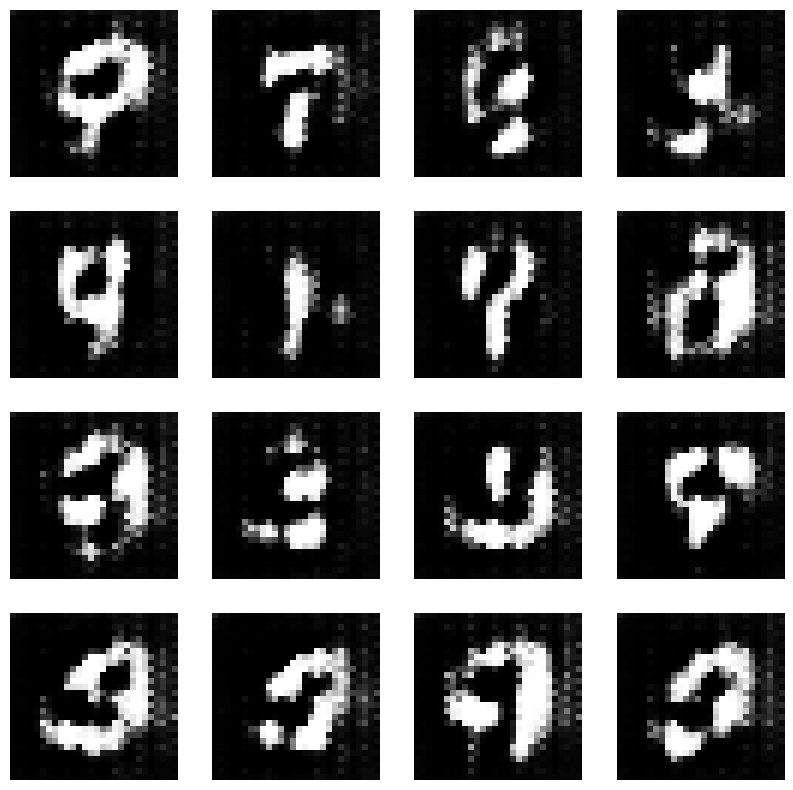

Epoch 14 complete


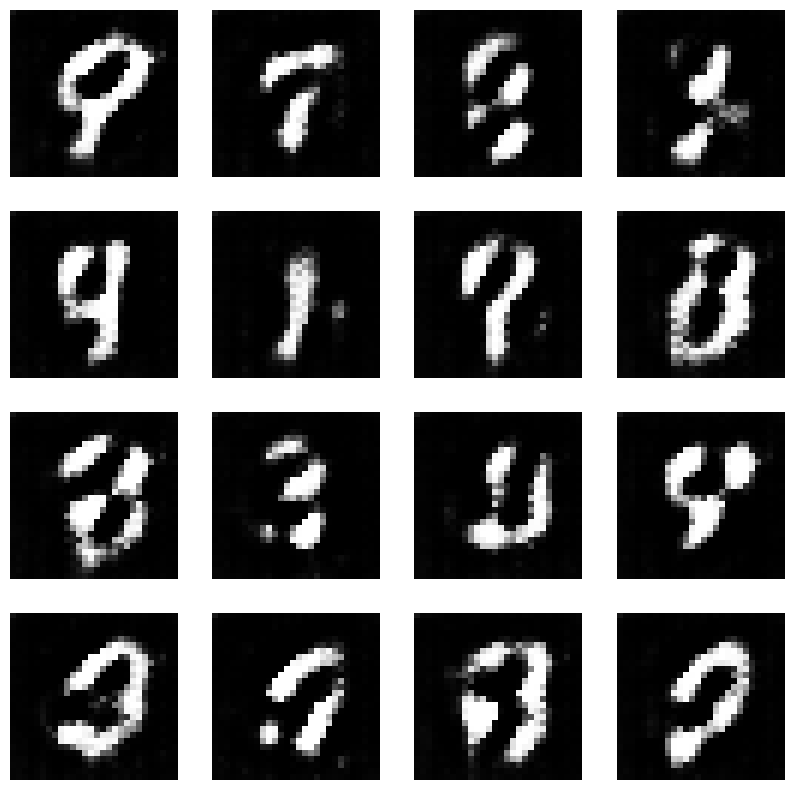

Epoch 15 complete


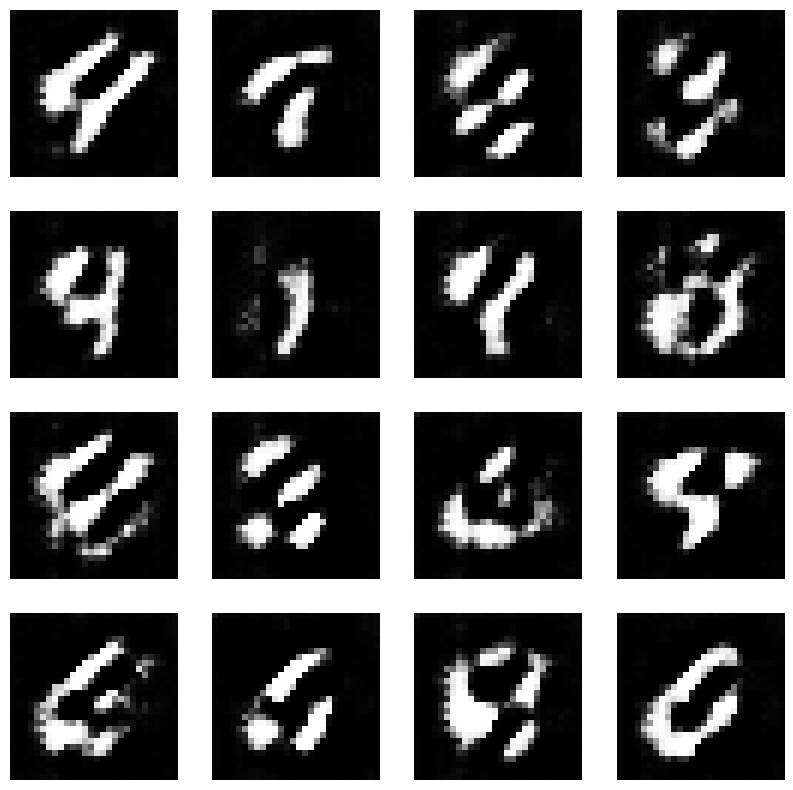

Epoch 16 complete


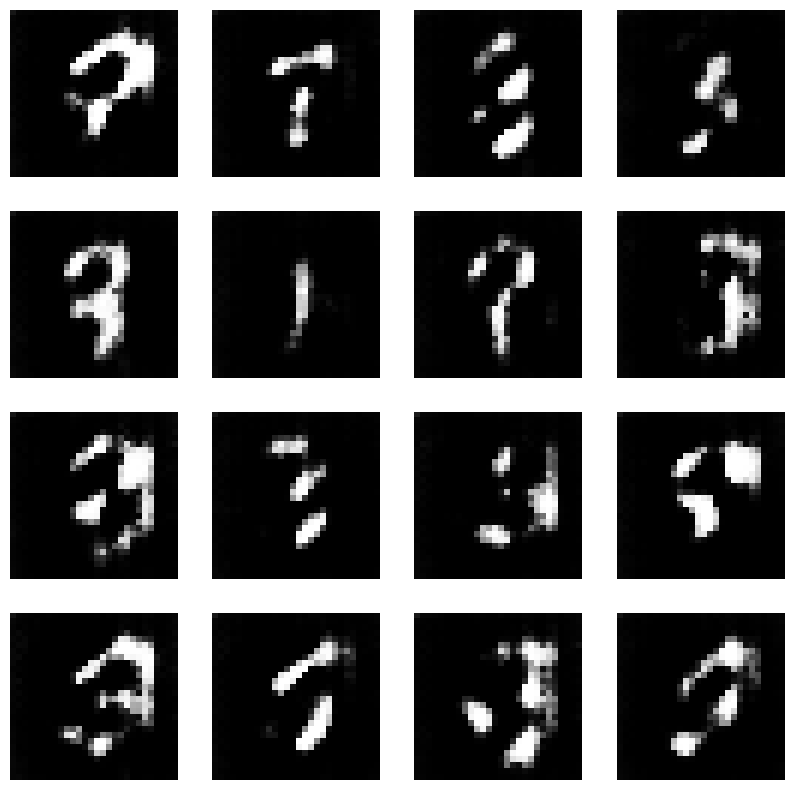

Epoch 17 complete


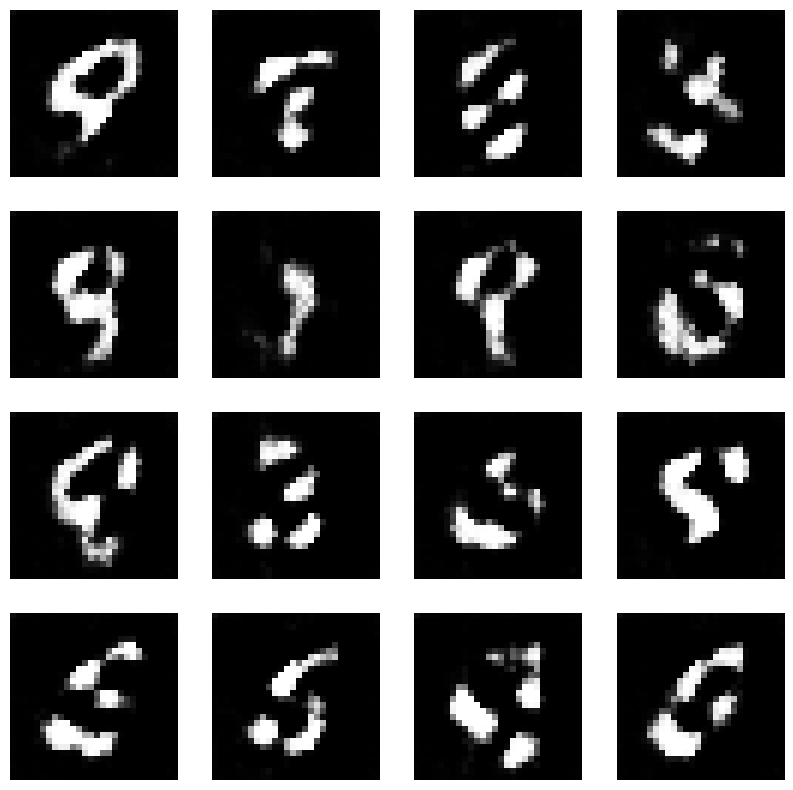

Epoch 18 complete


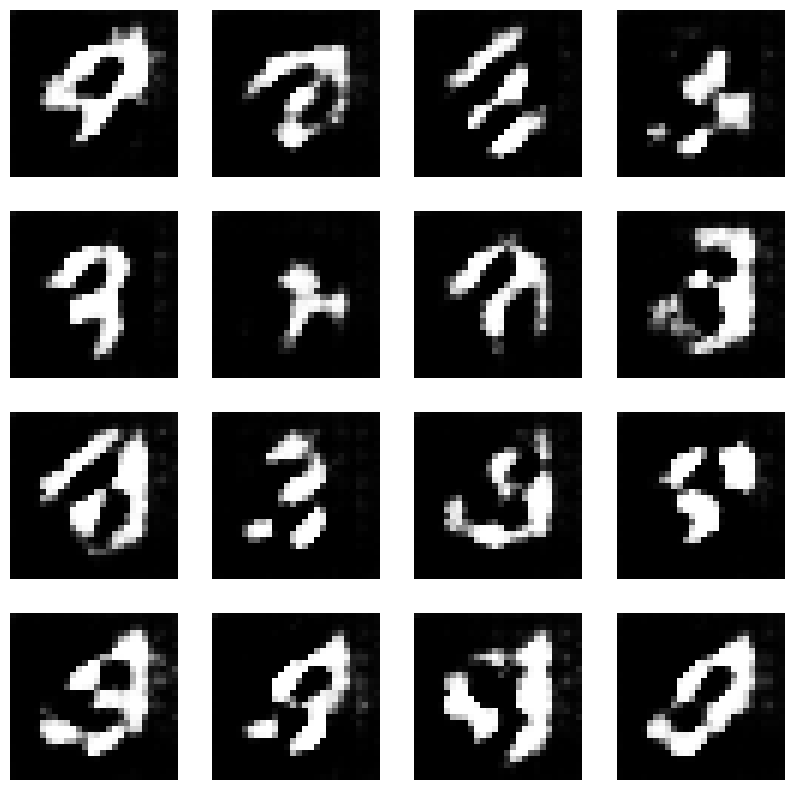

Epoch 19 complete


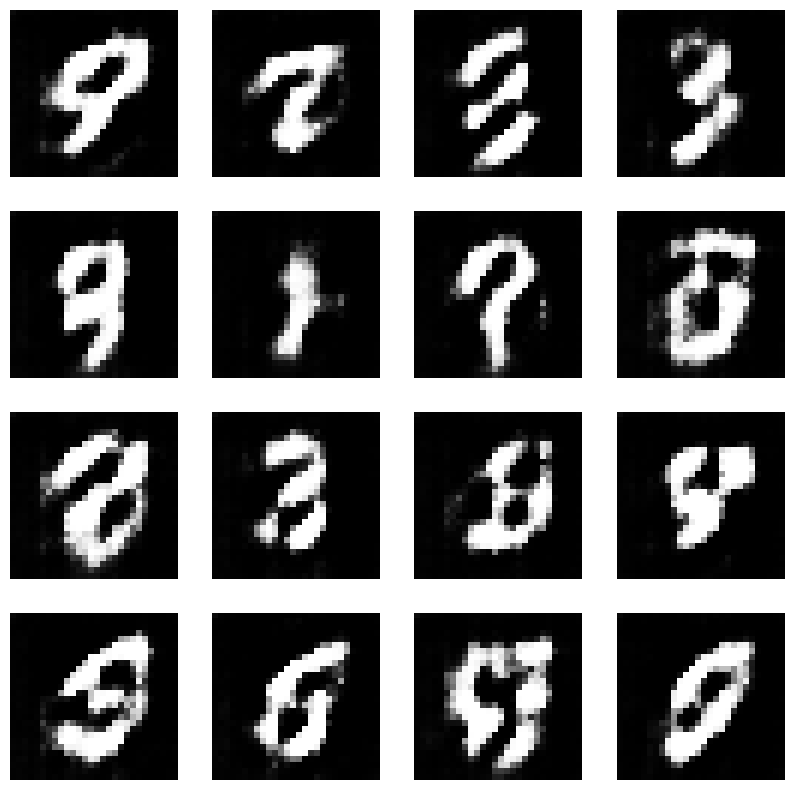

Epoch 20 complete


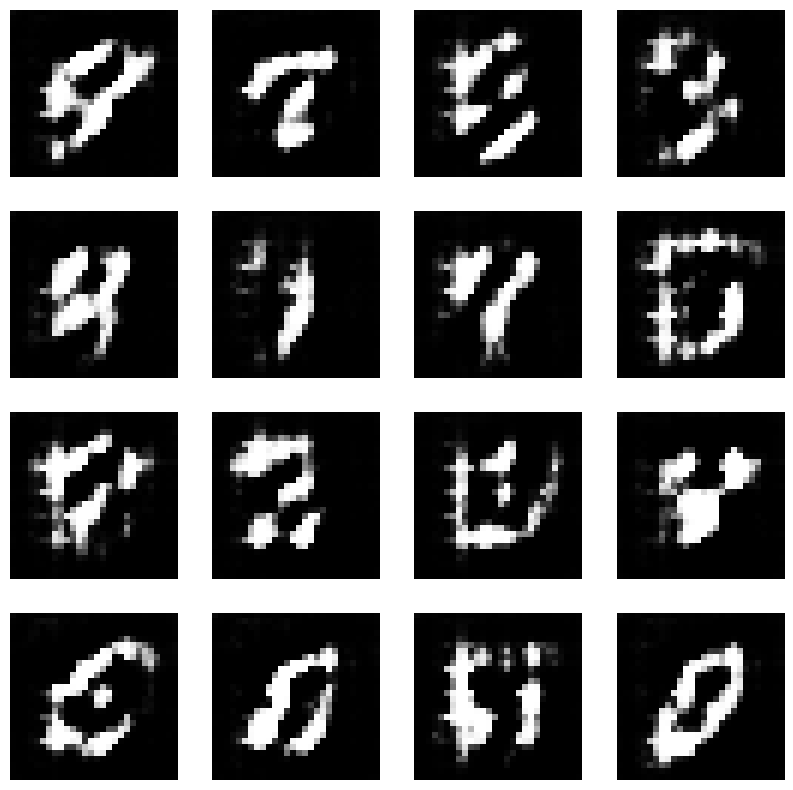

Epoch 21 complete


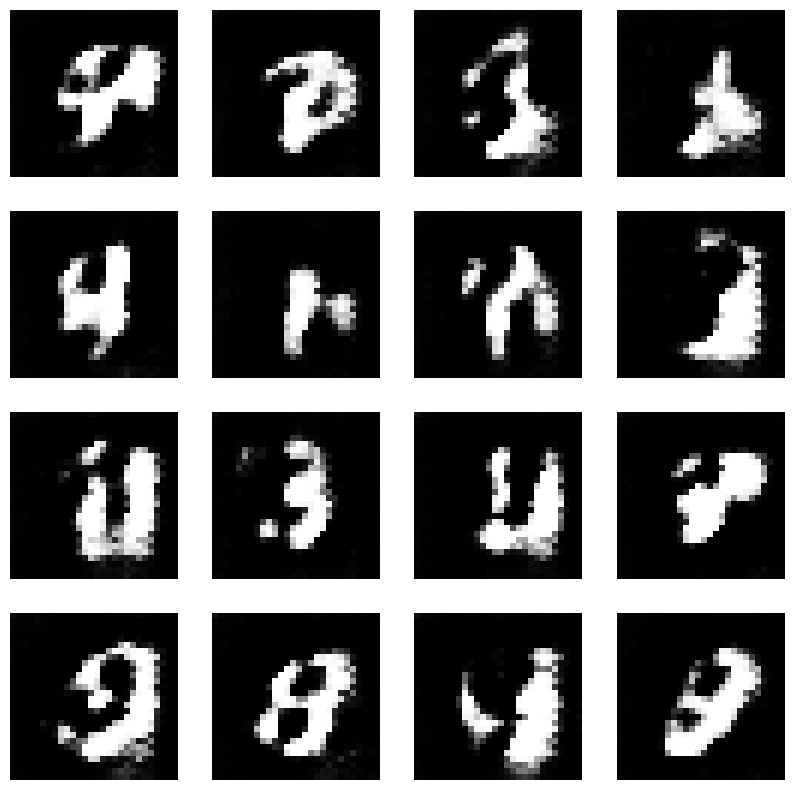

Epoch 22 complete


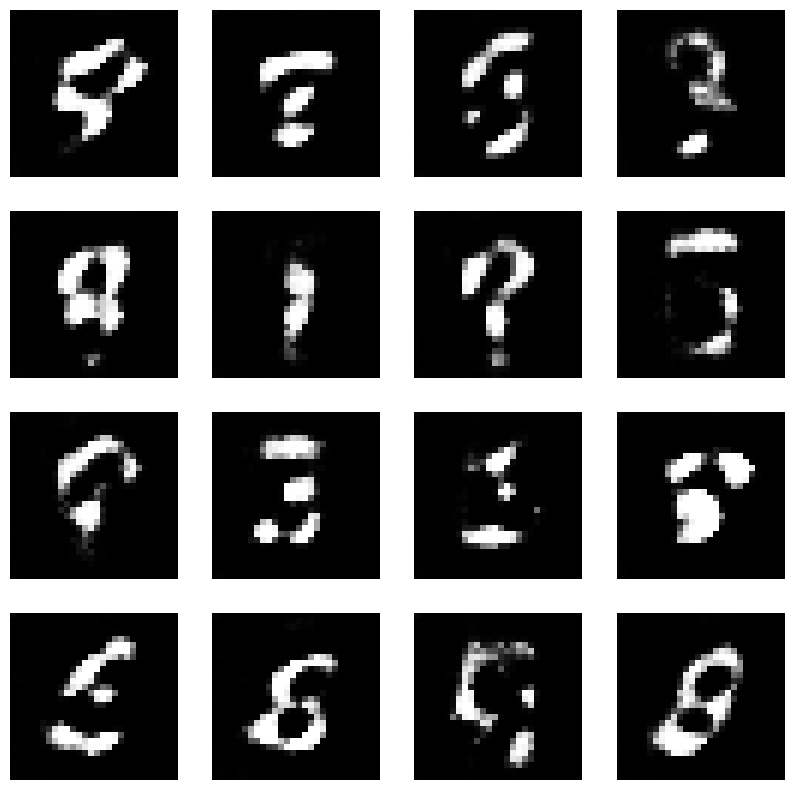

Epoch 23 complete


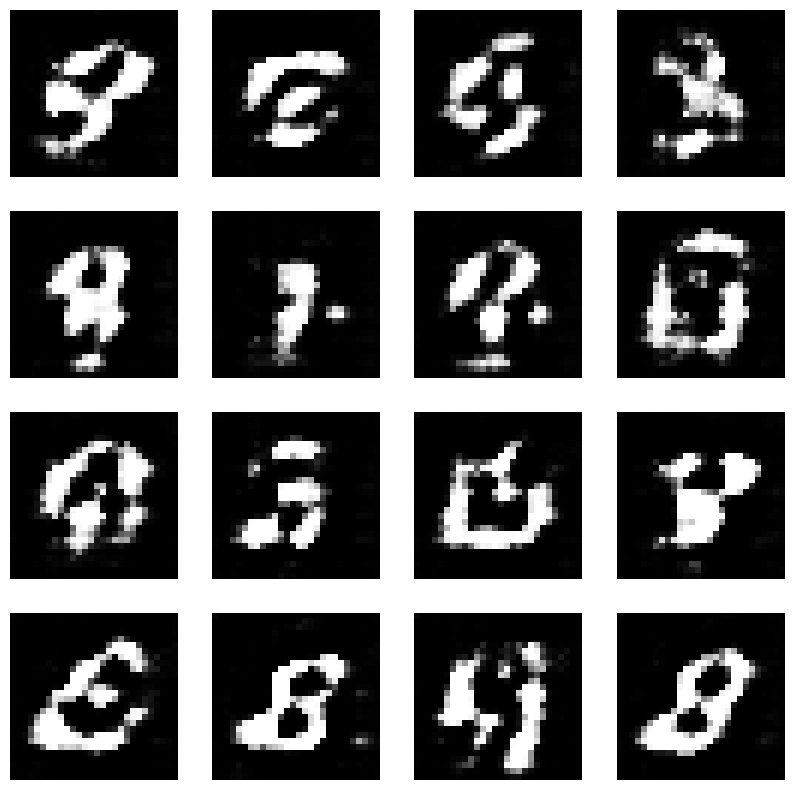

Epoch 24 complete


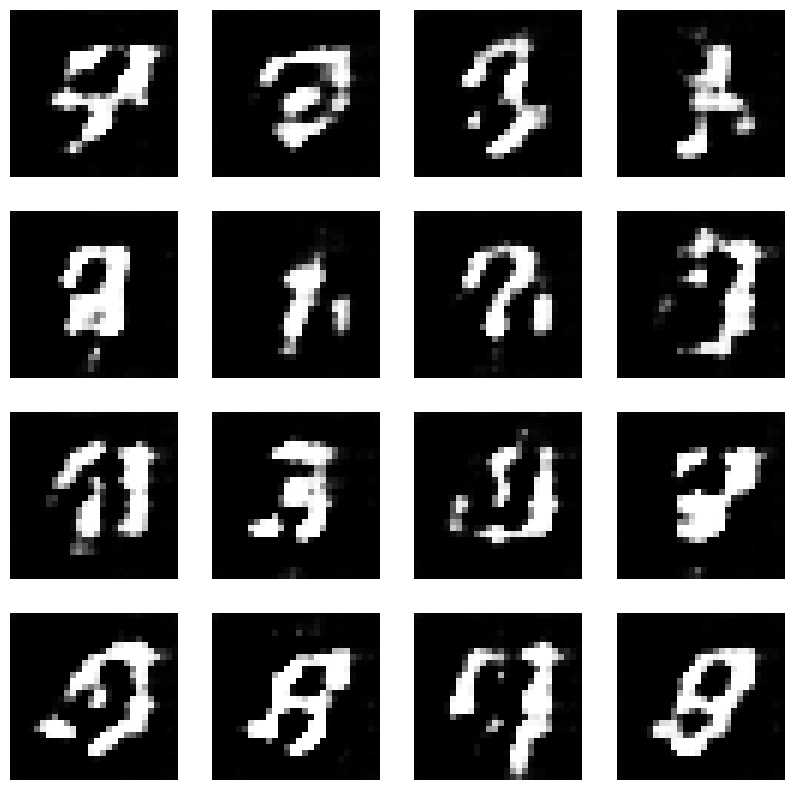

Epoch 25 complete


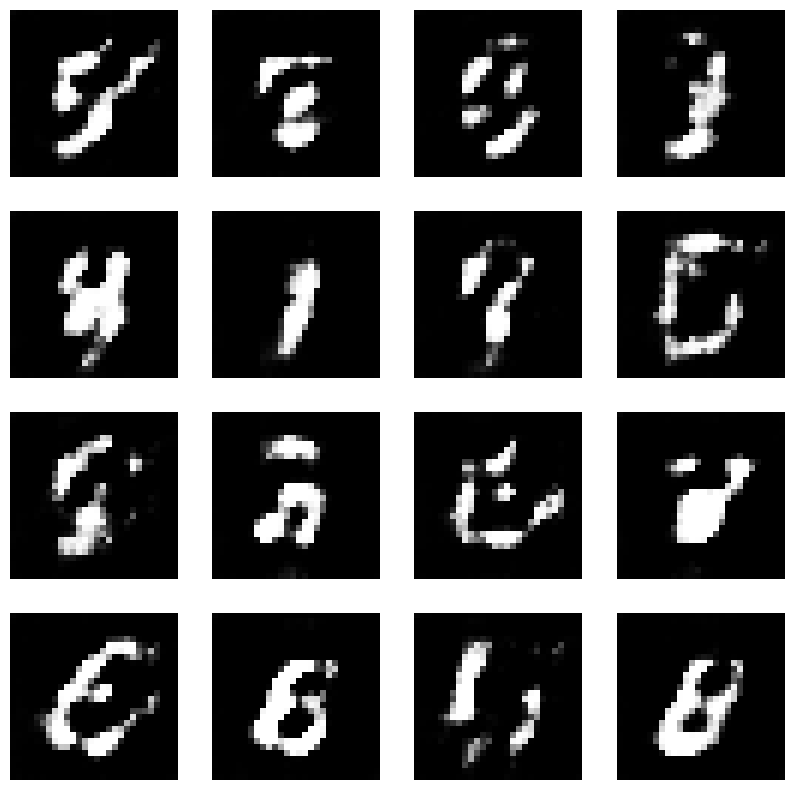

Epoch 26 complete


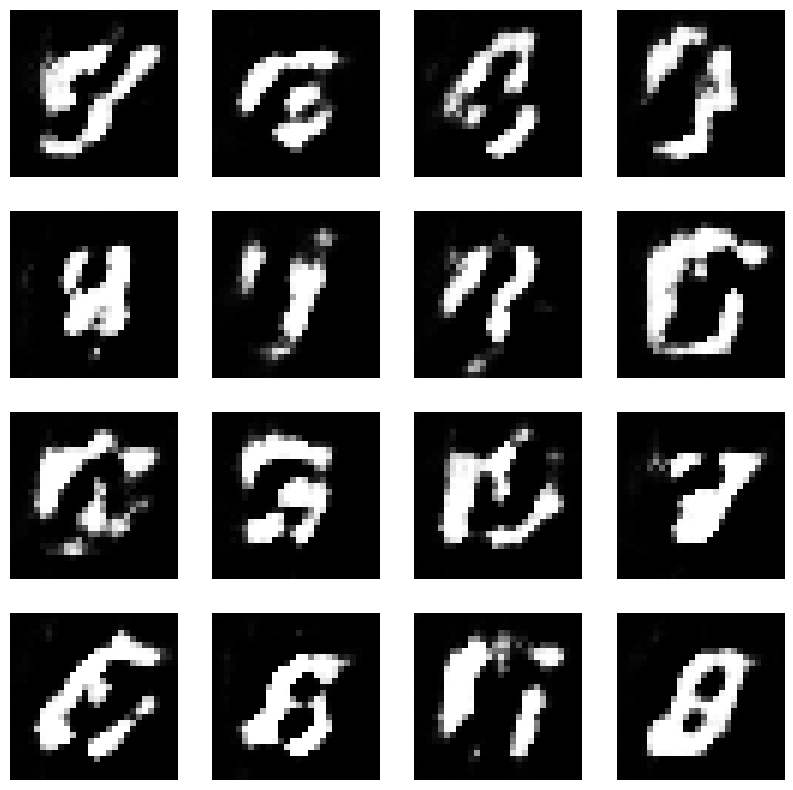

Epoch 27 complete


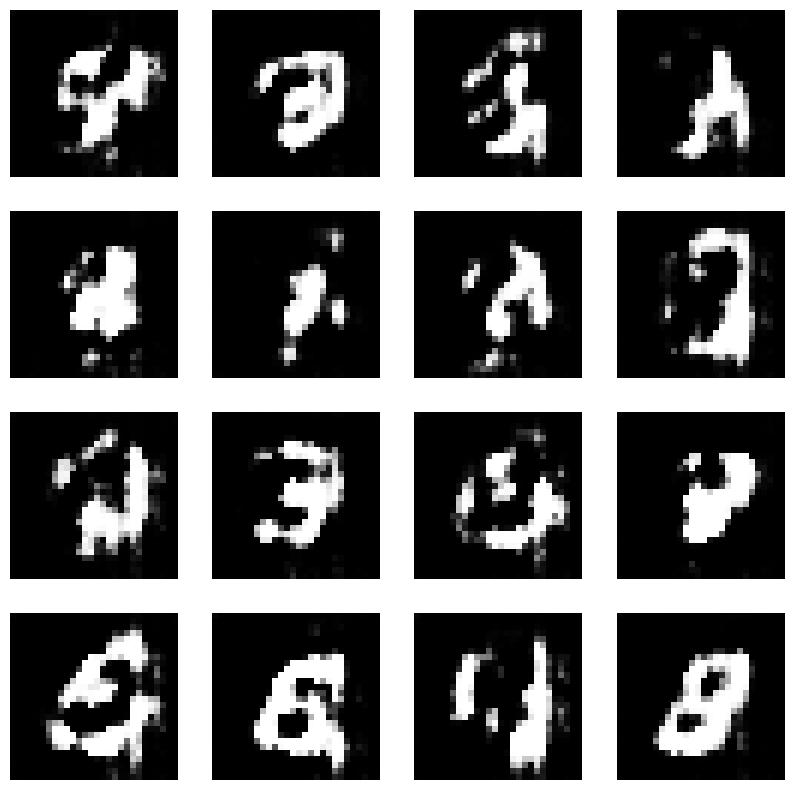

Epoch 28 complete


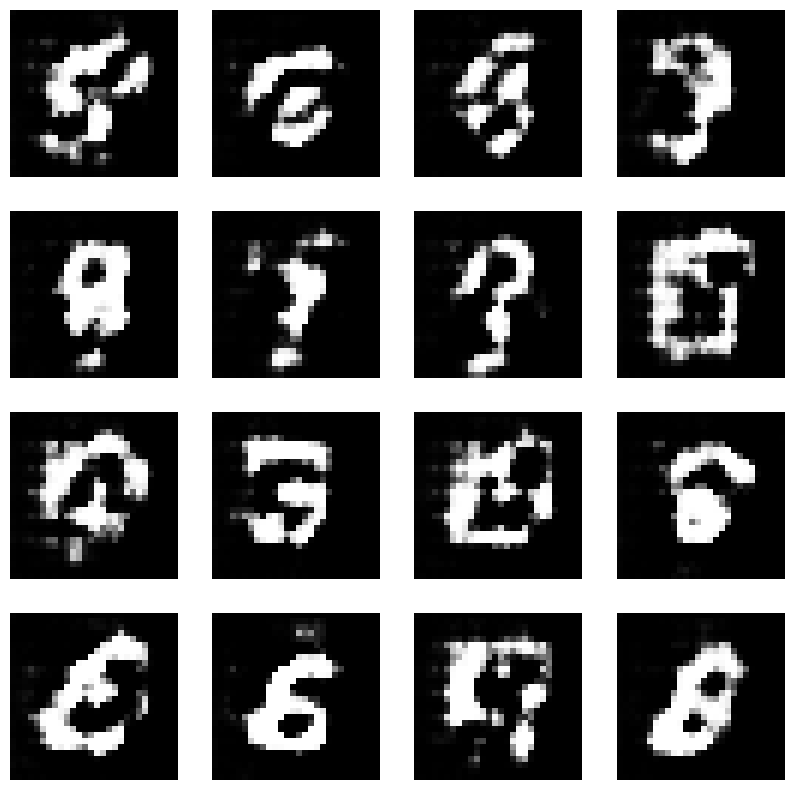

Epoch 29 complete


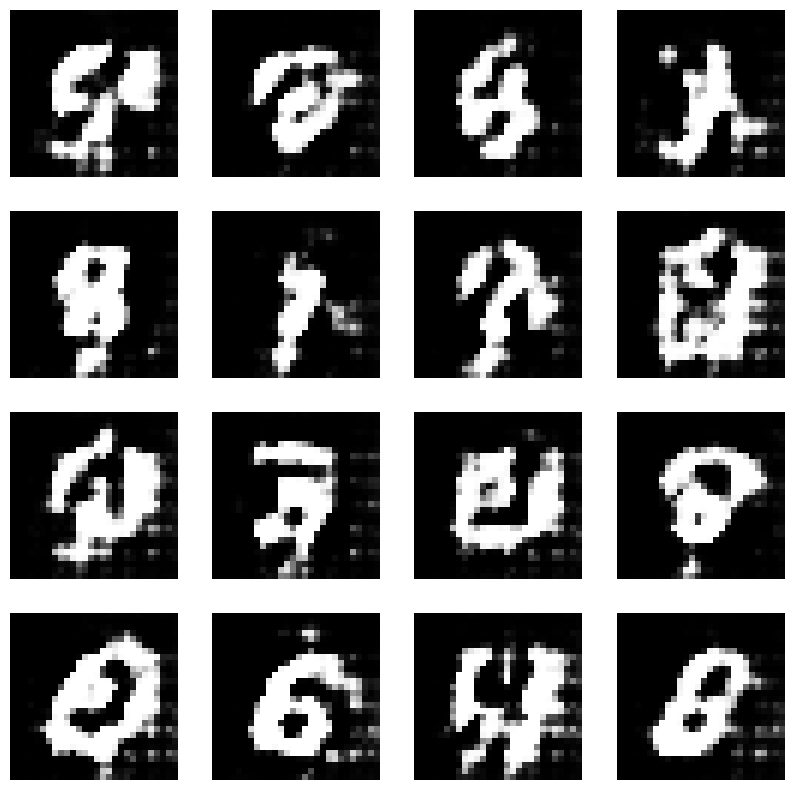

Epoch 30 complete


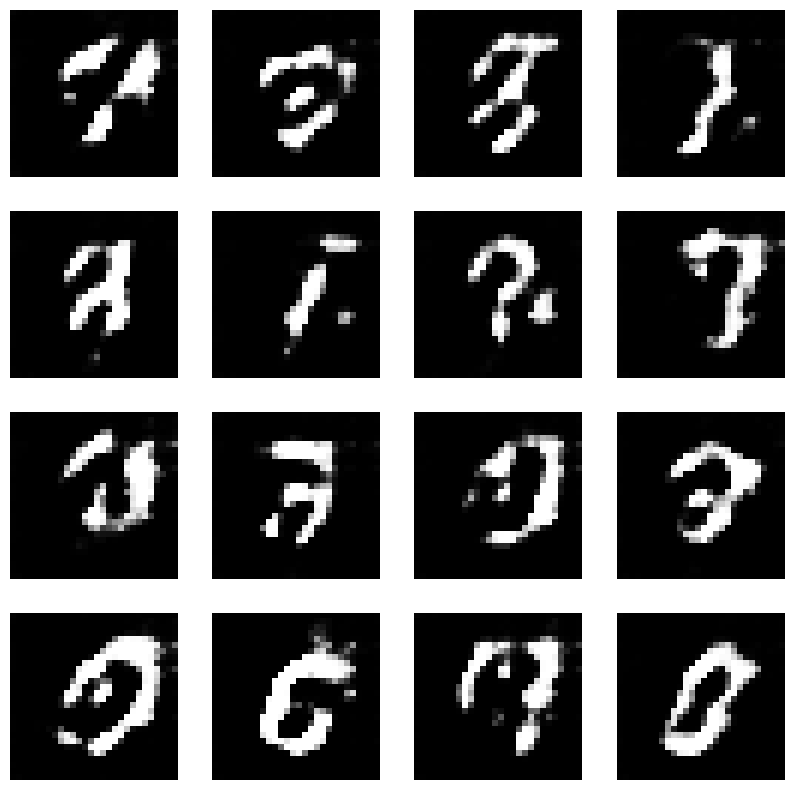

Epoch 31 complete


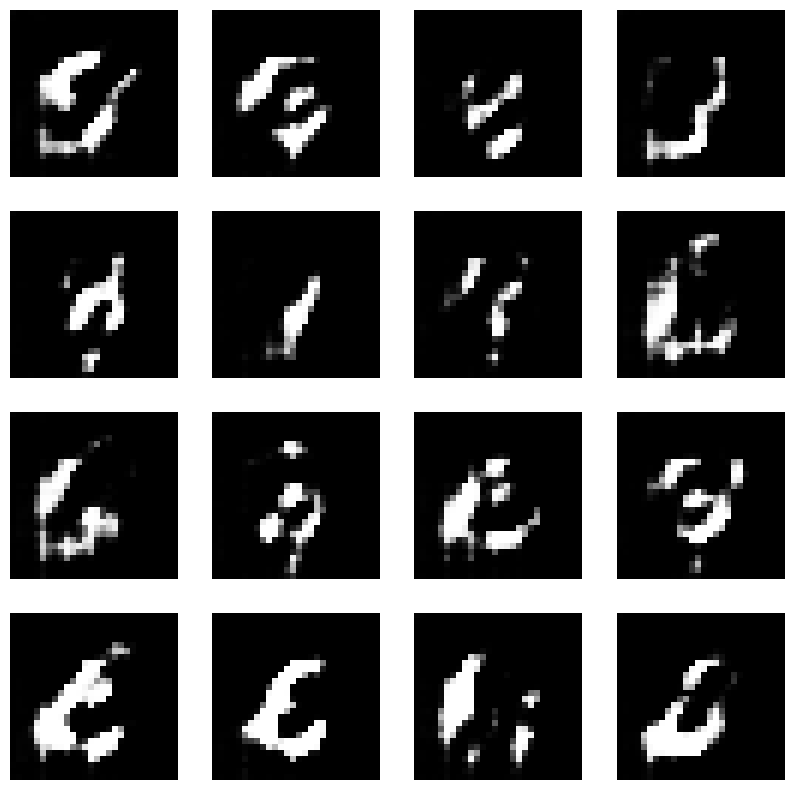

Epoch 32 complete


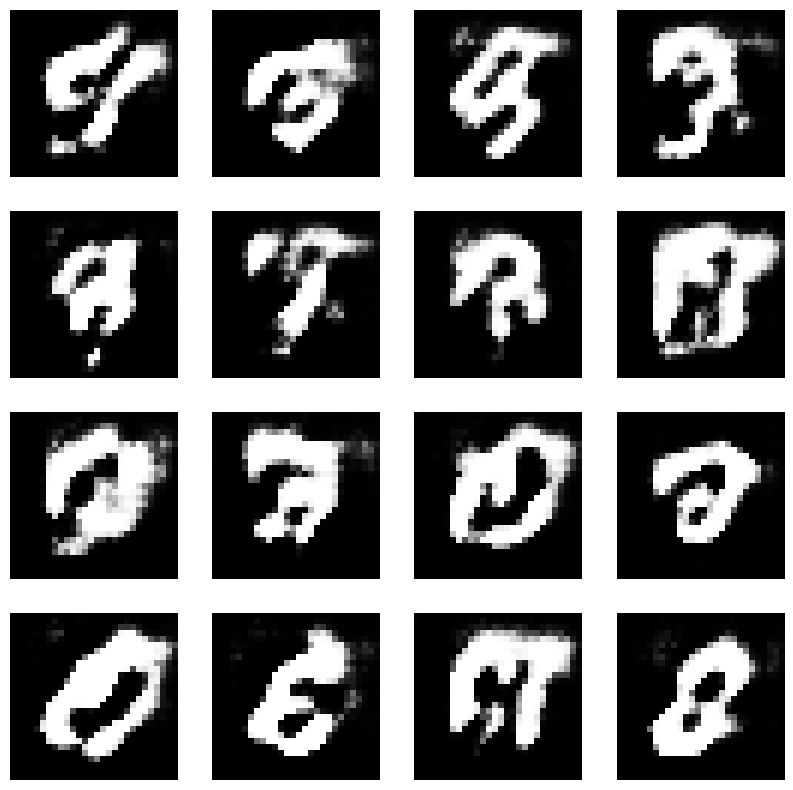

Epoch 33 complete


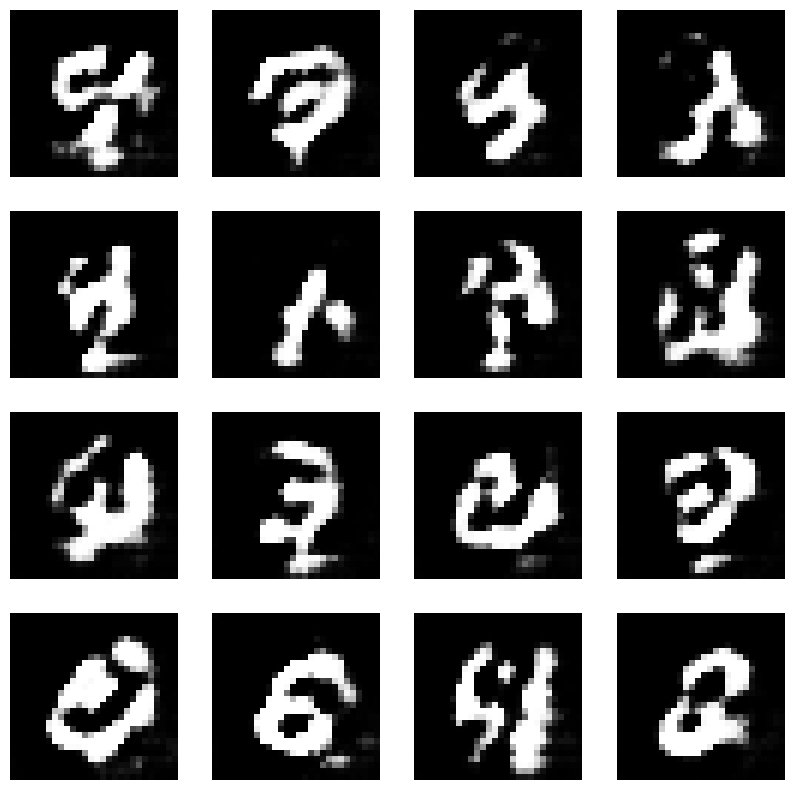

Epoch 34 complete


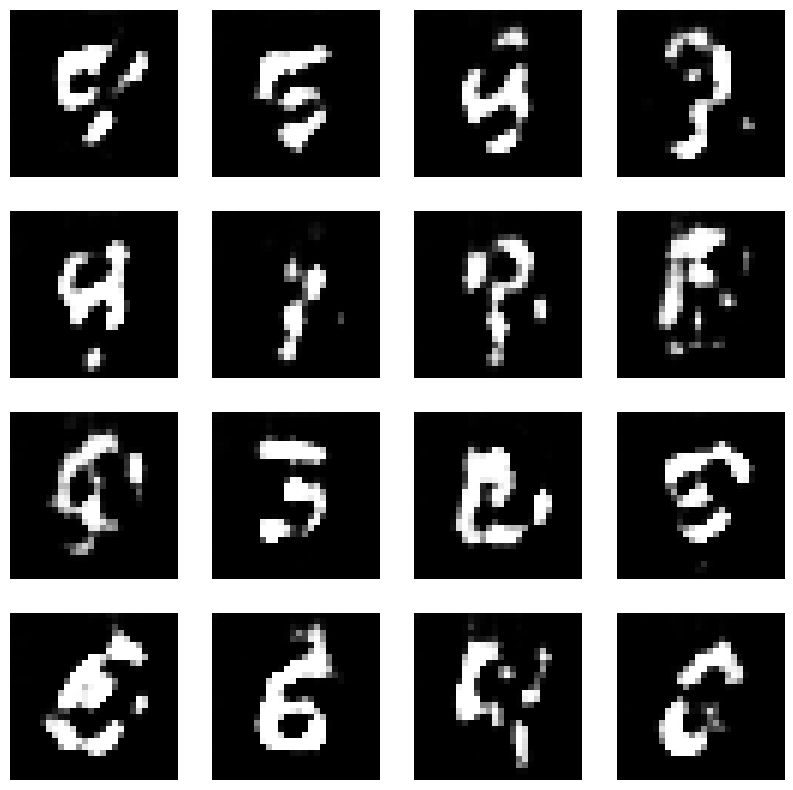

Epoch 35 complete


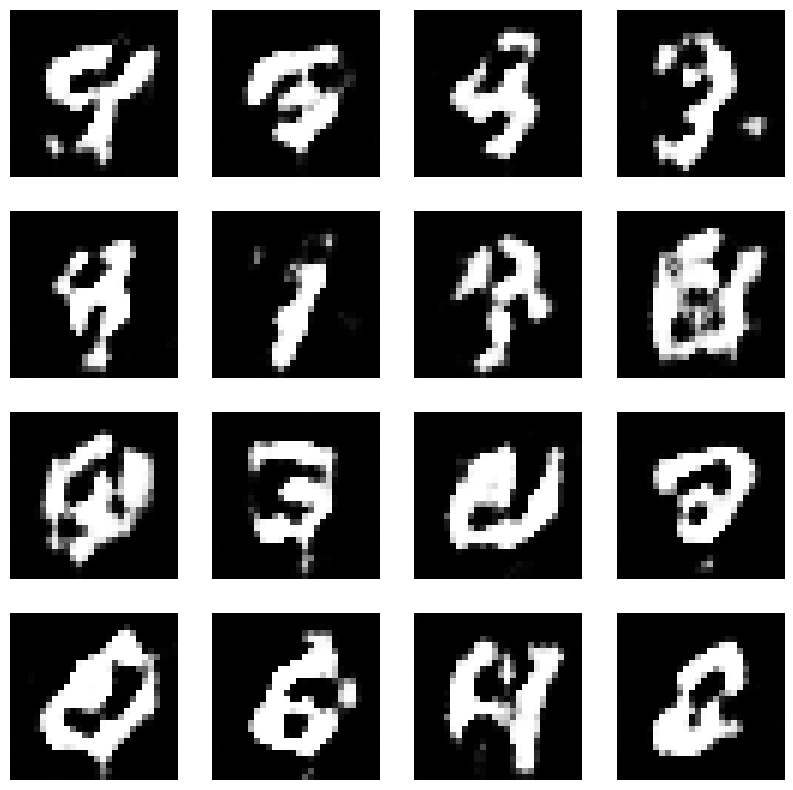

Epoch 36 complete


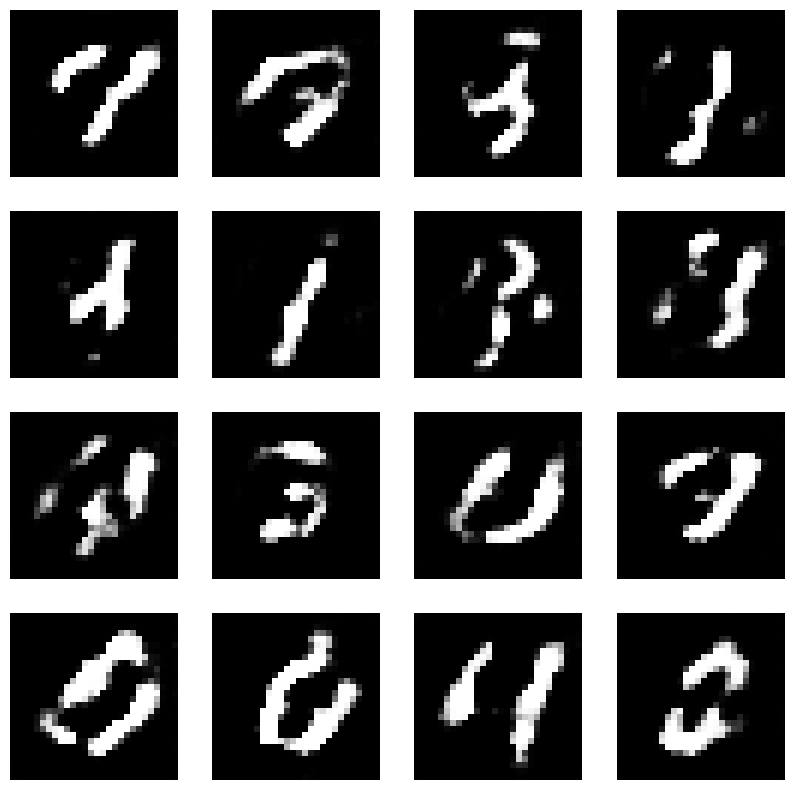

Epoch 37 complete


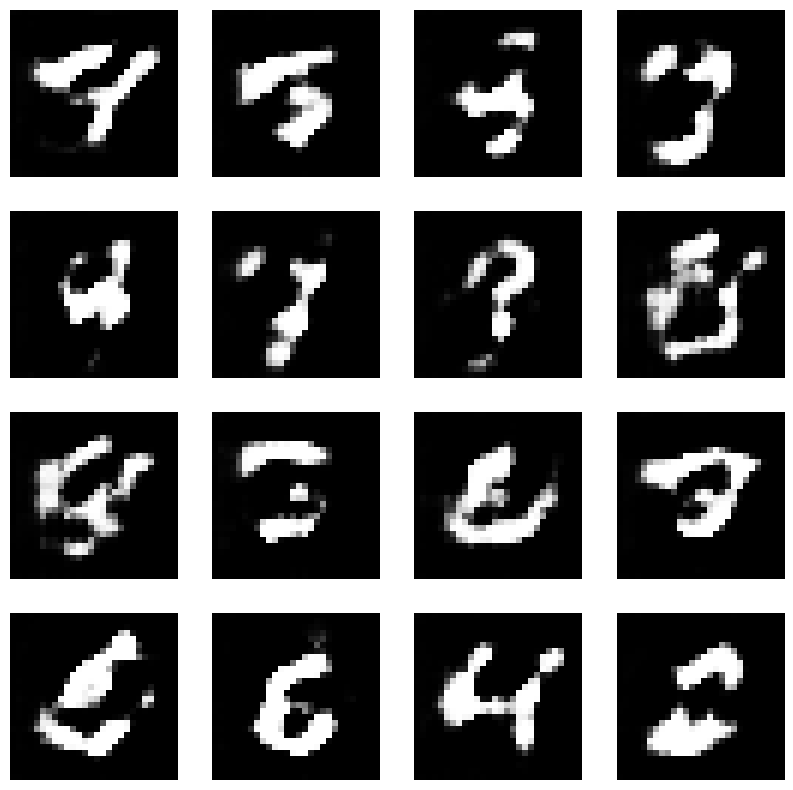

Epoch 38 complete


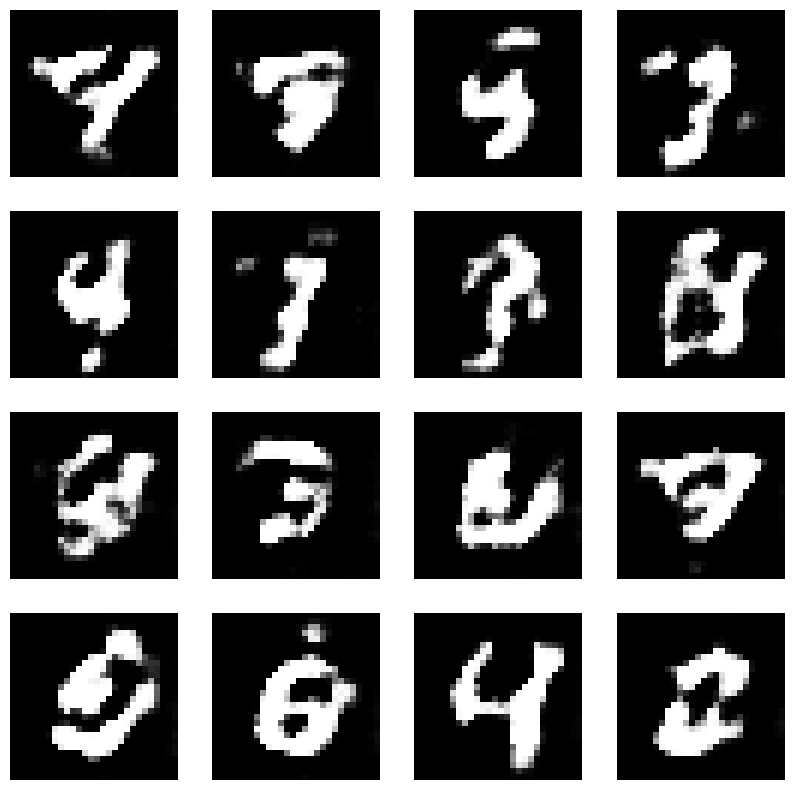

Epoch 39 complete


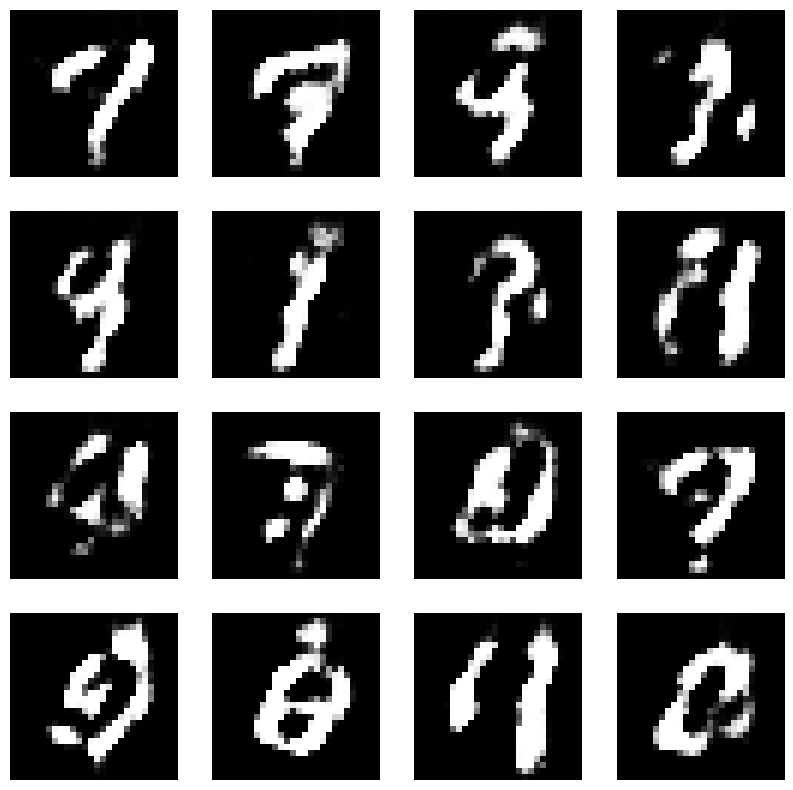

Epoch 40 complete


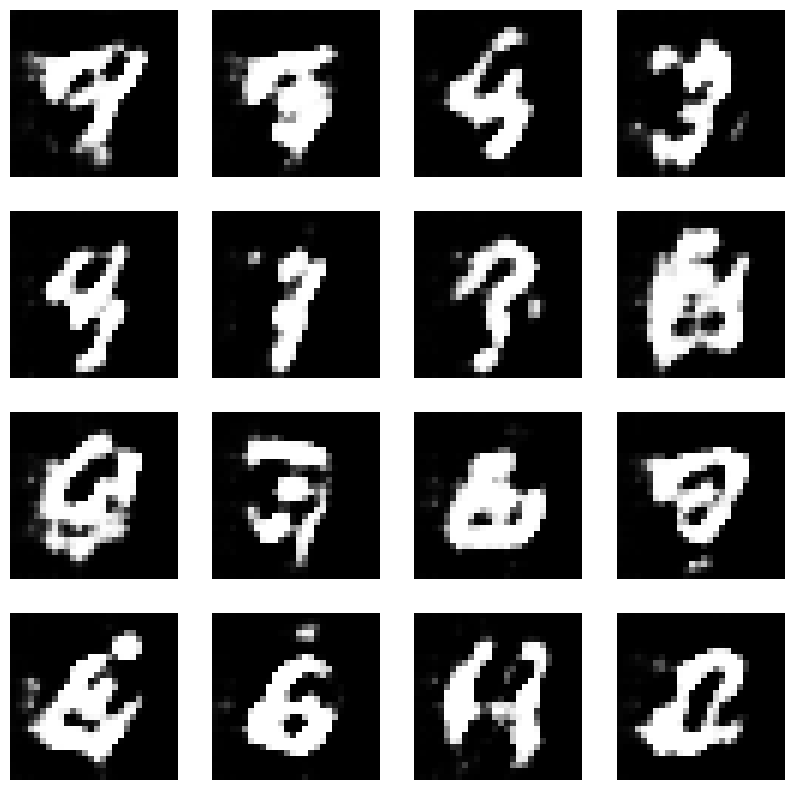

Epoch 41 complete


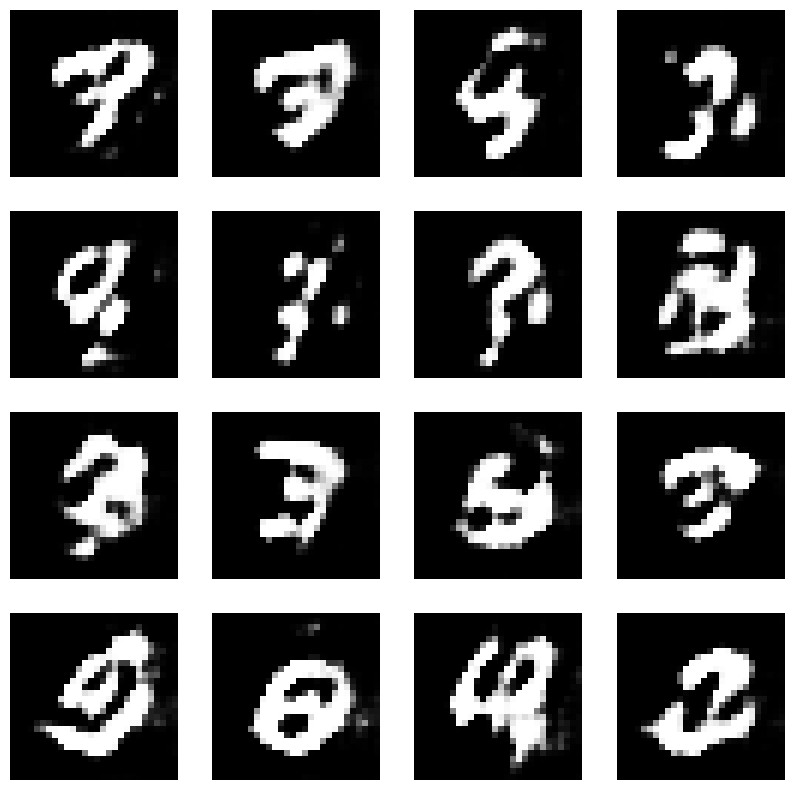

Epoch 42 complete


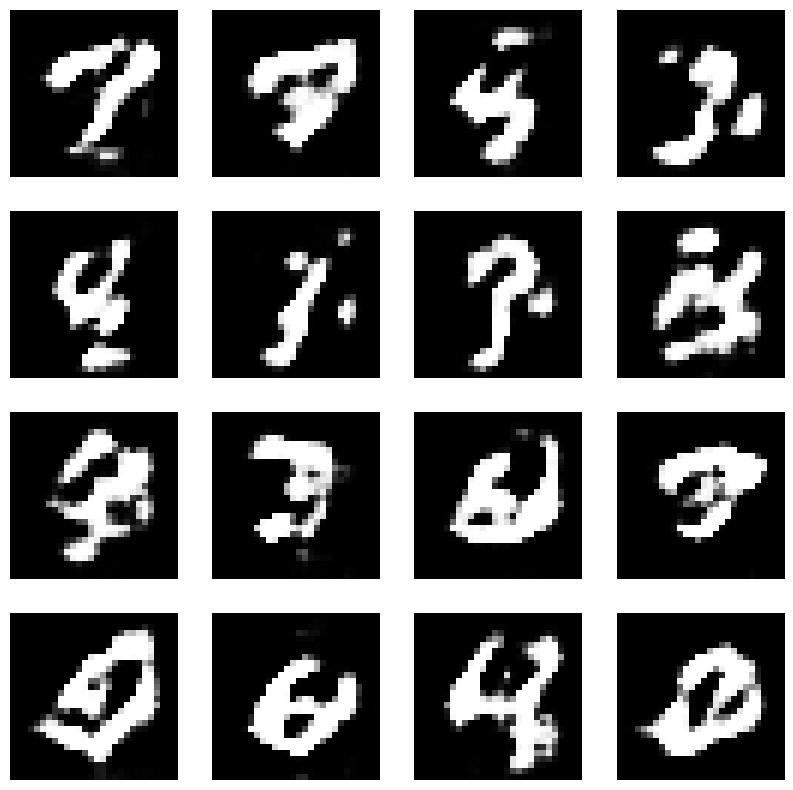

Epoch 43 complete


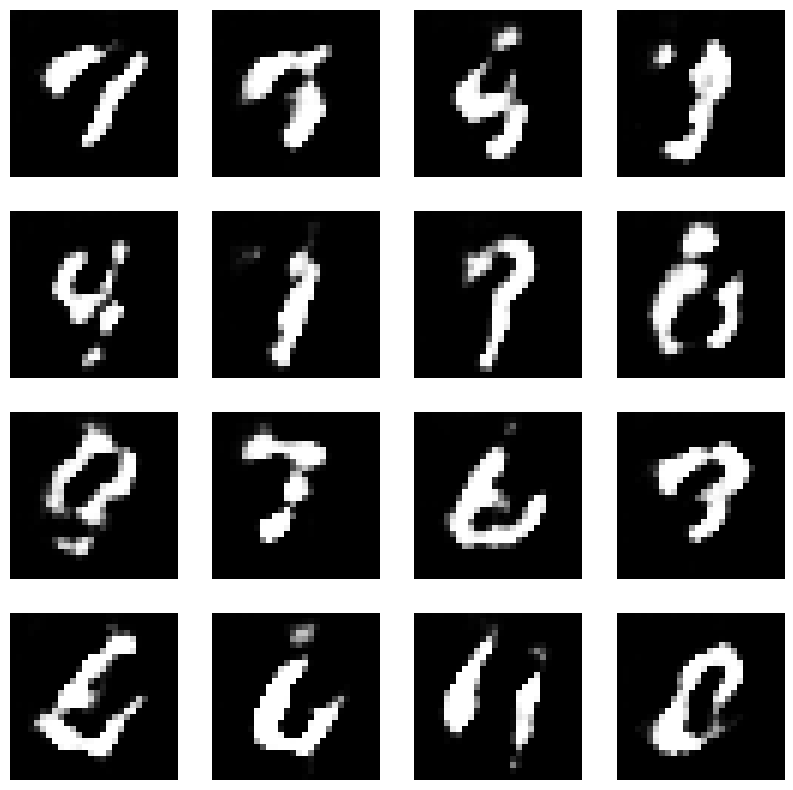

Epoch 44 complete


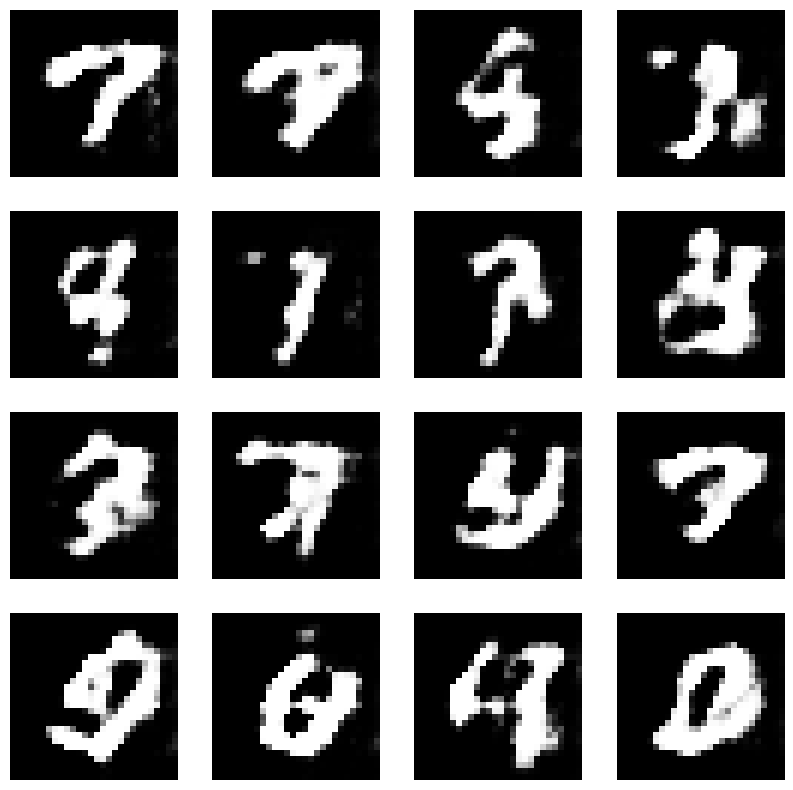

Epoch 45 complete


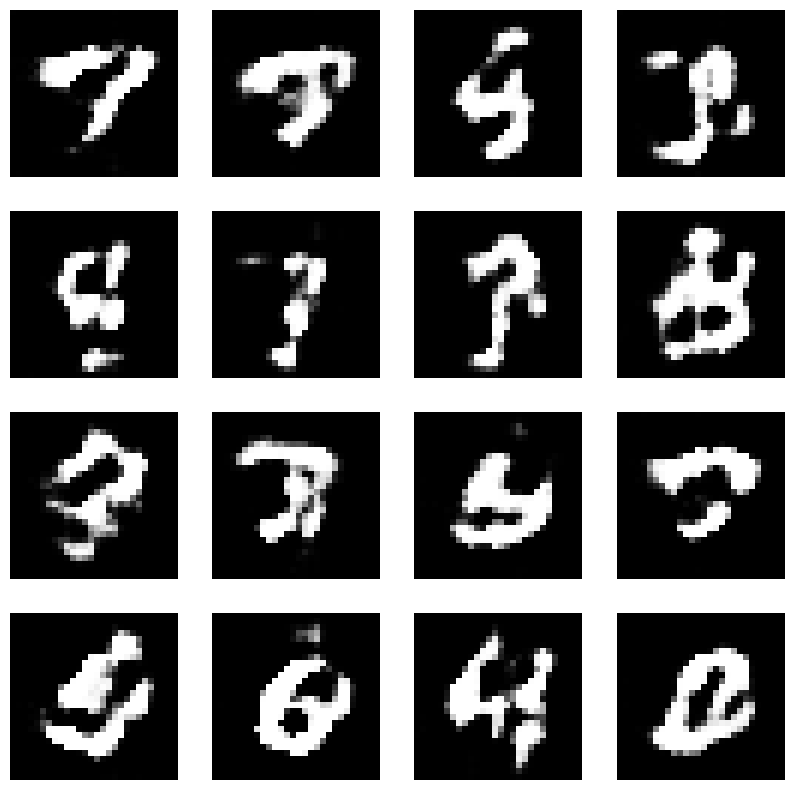

Epoch 46 complete


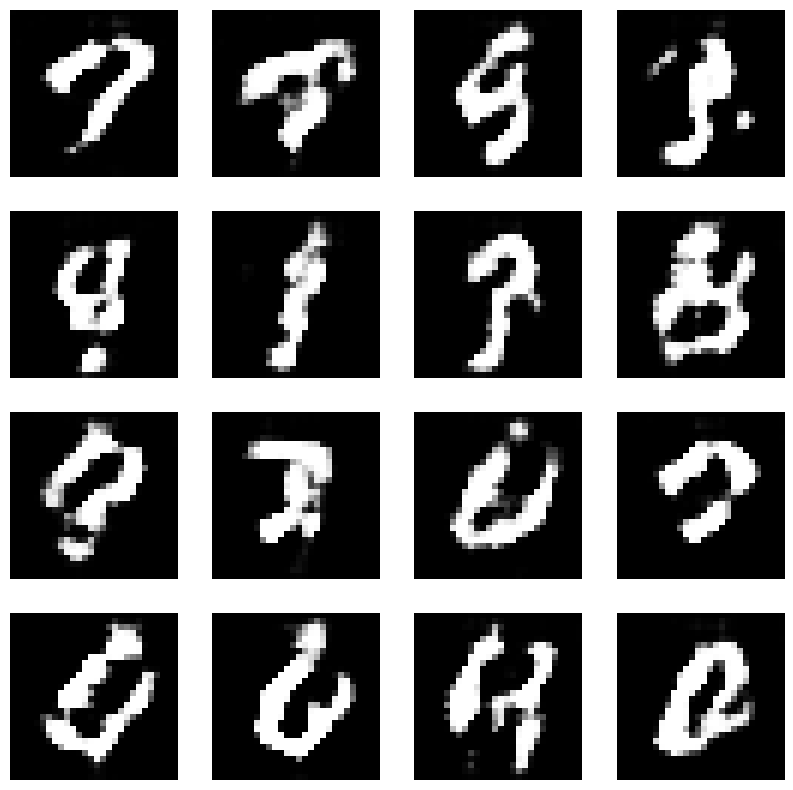

Epoch 47 complete


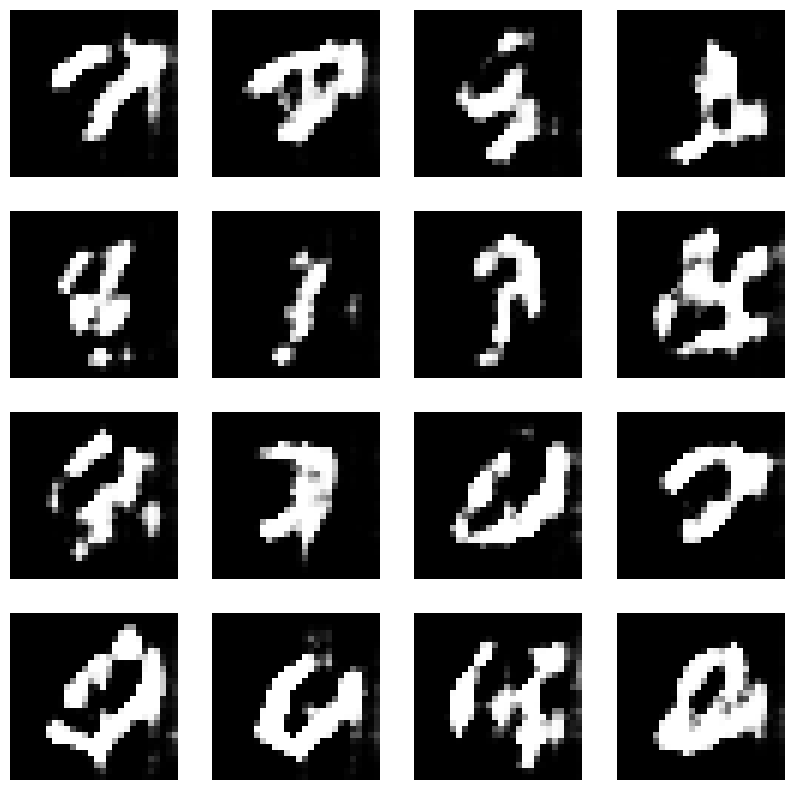

Epoch 48 complete


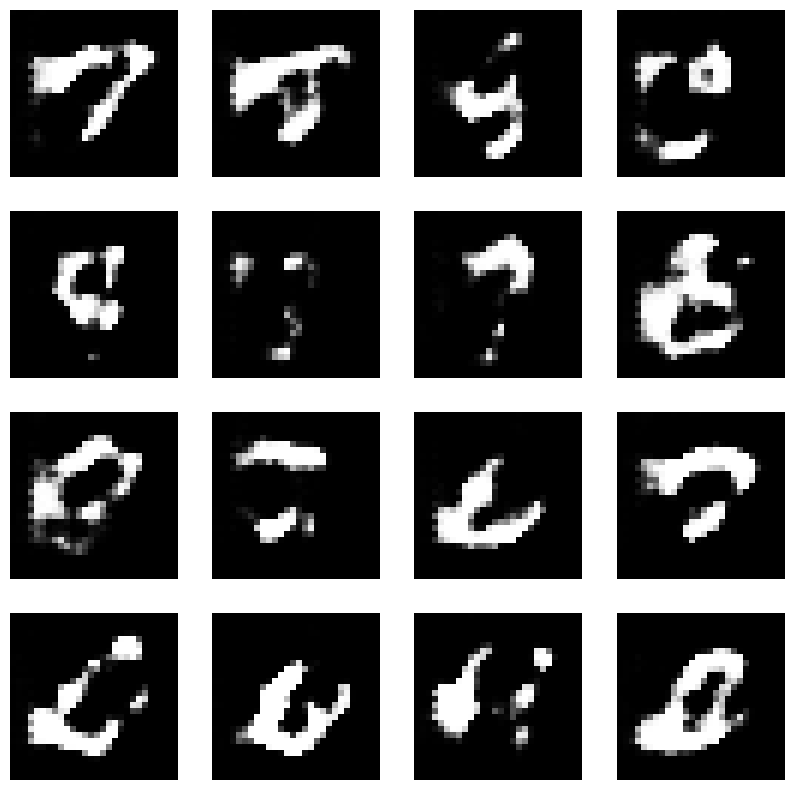

Epoch 49 complete


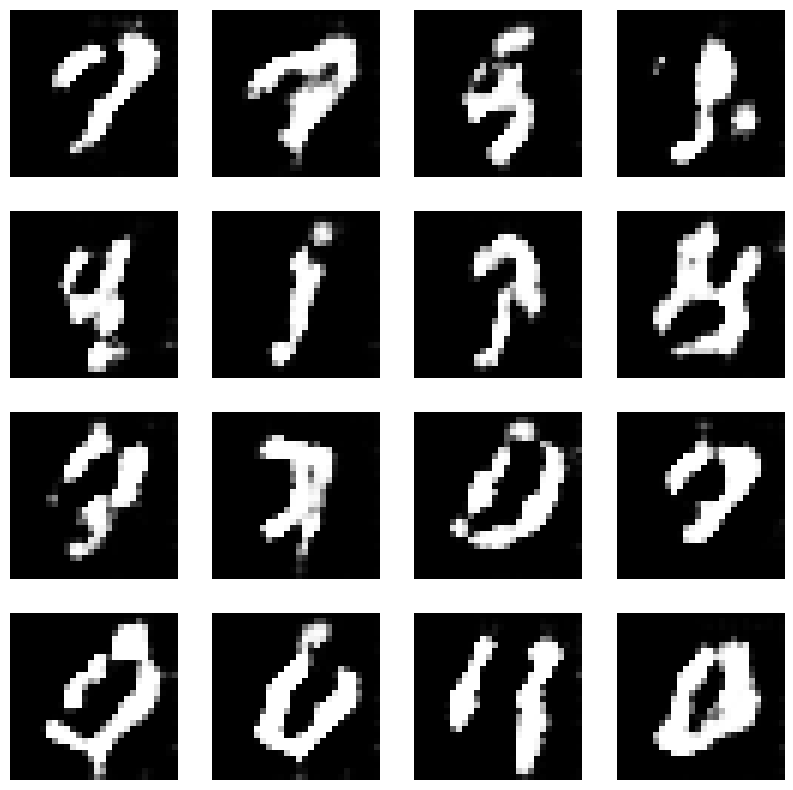

Epoch 50 complete


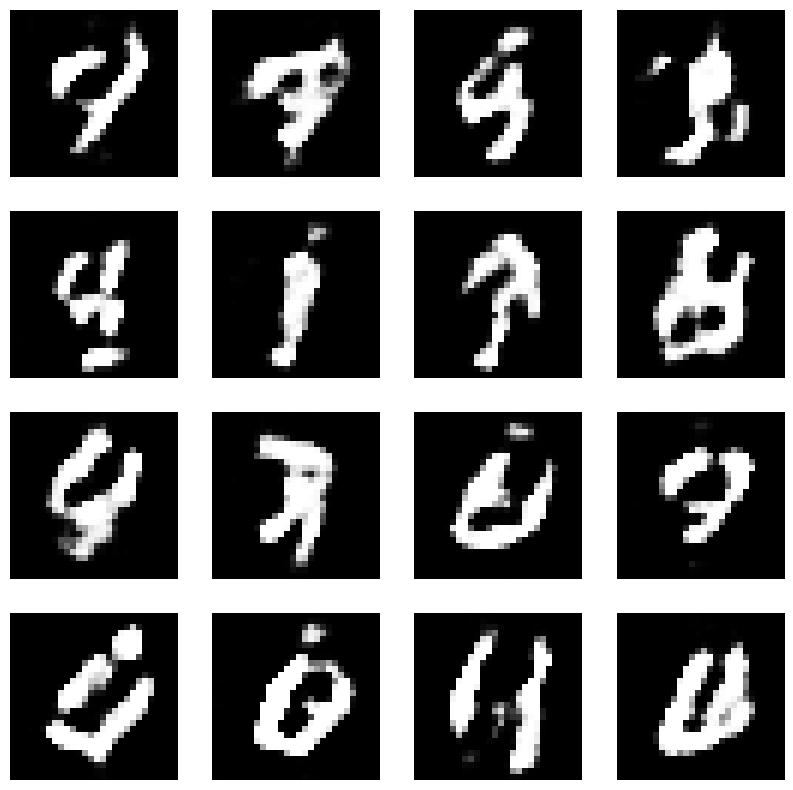

Epoch 51 complete


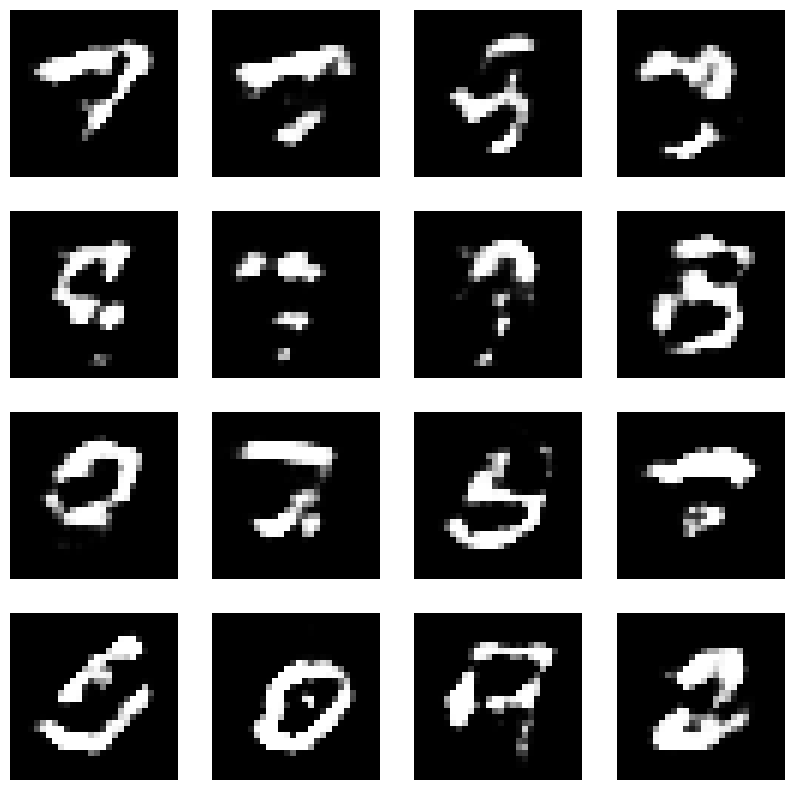

Epoch 52 complete


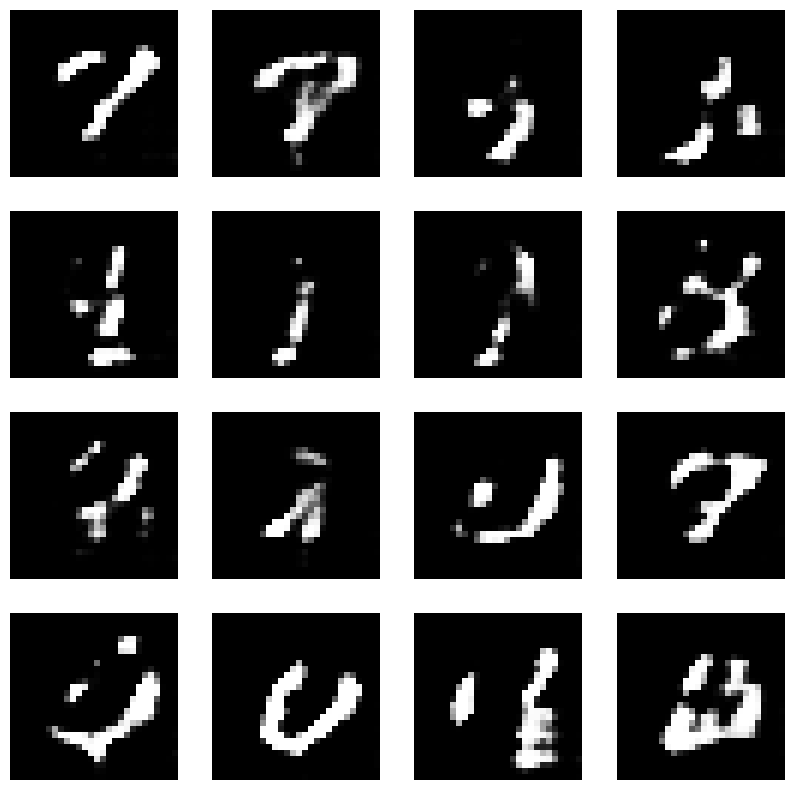

Epoch 53 complete


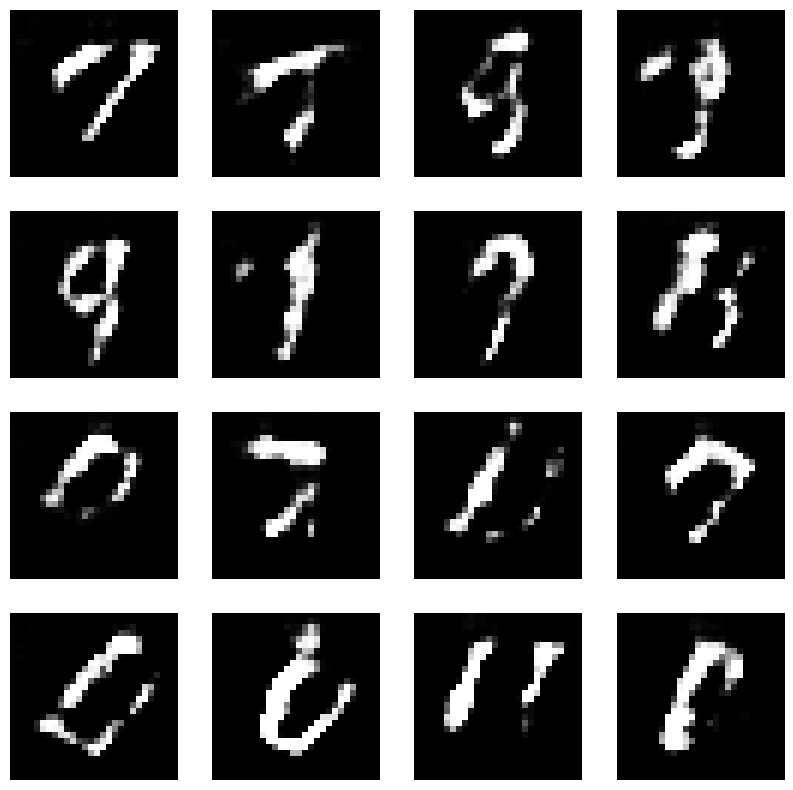

Epoch 54 complete


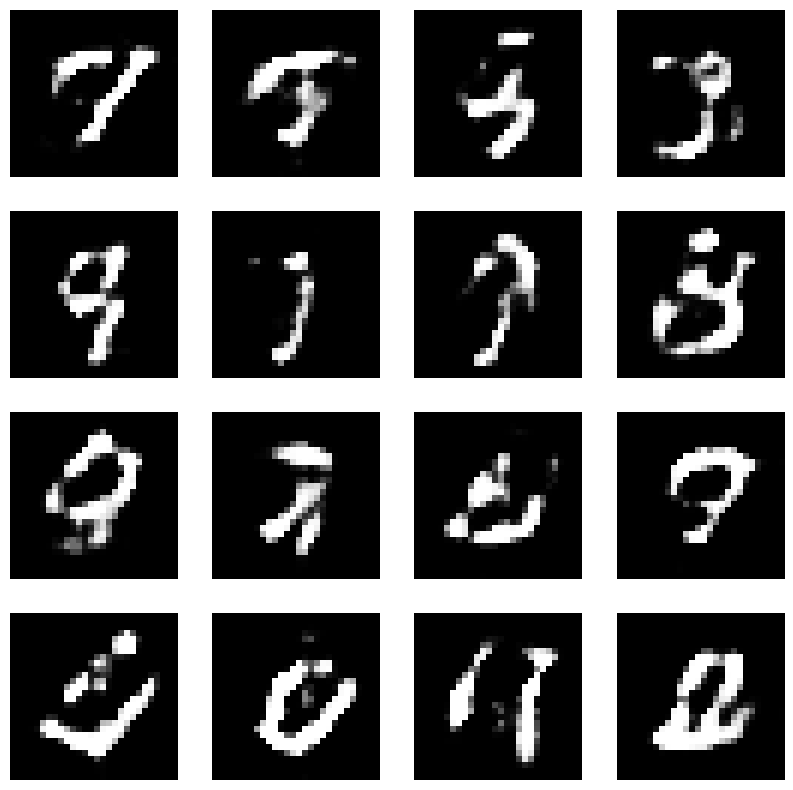

Epoch 55 complete


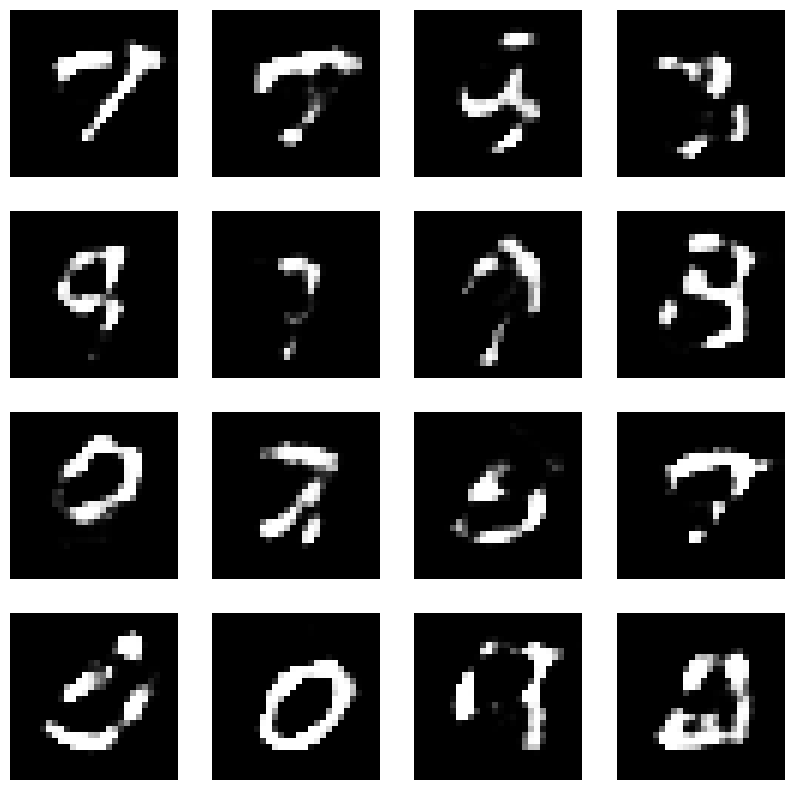

Epoch 56 complete


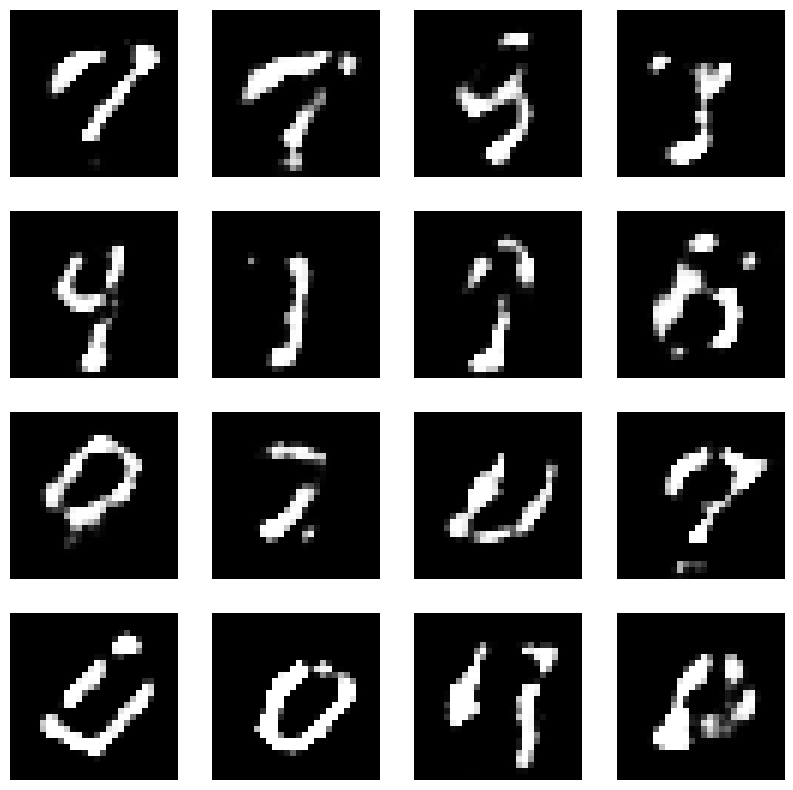

Epoch 57 complete


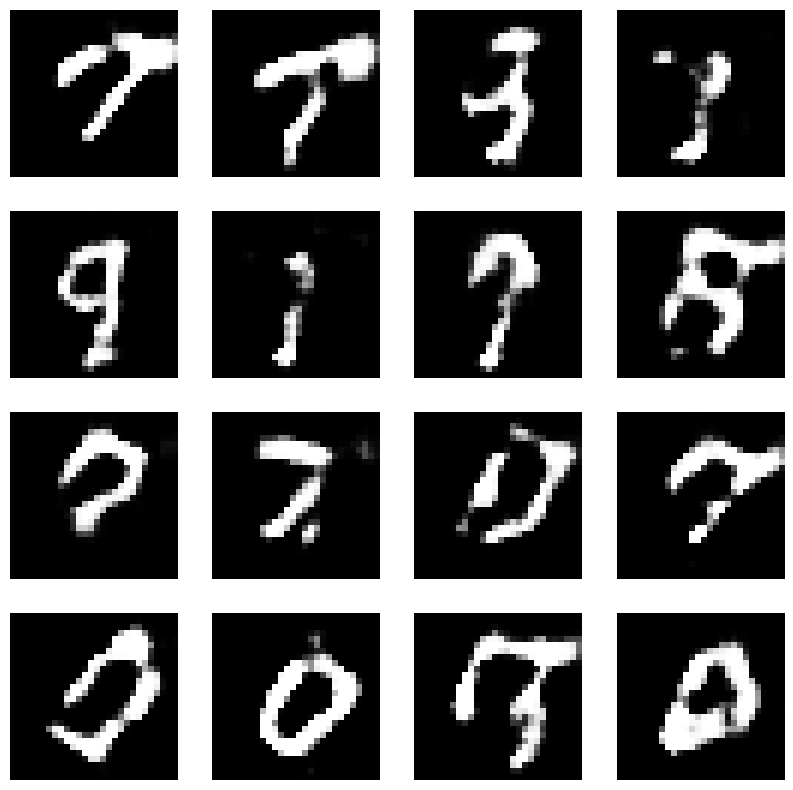

Epoch 58 complete


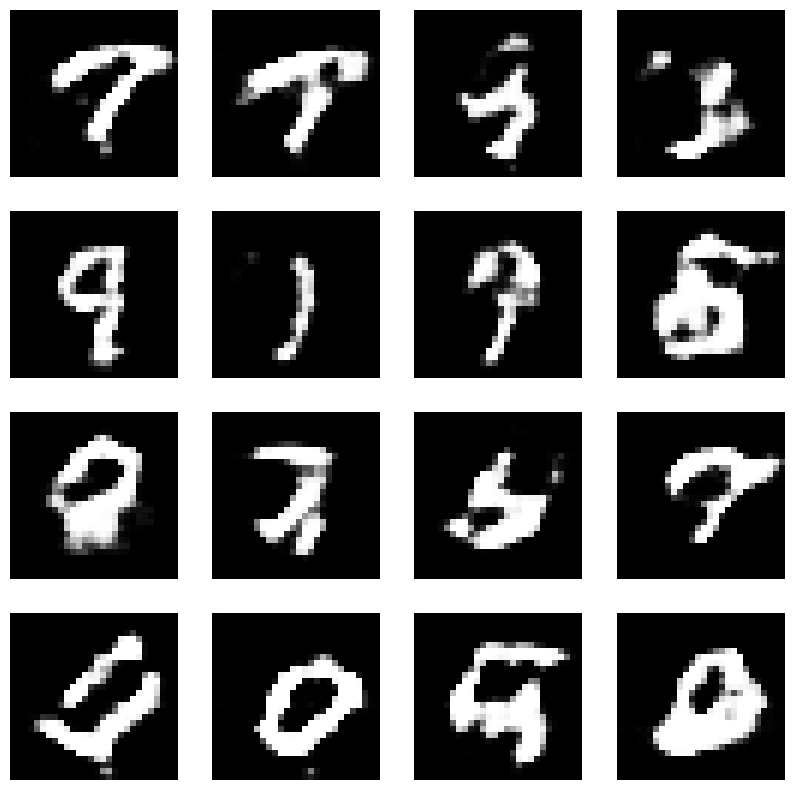

Epoch 59 complete


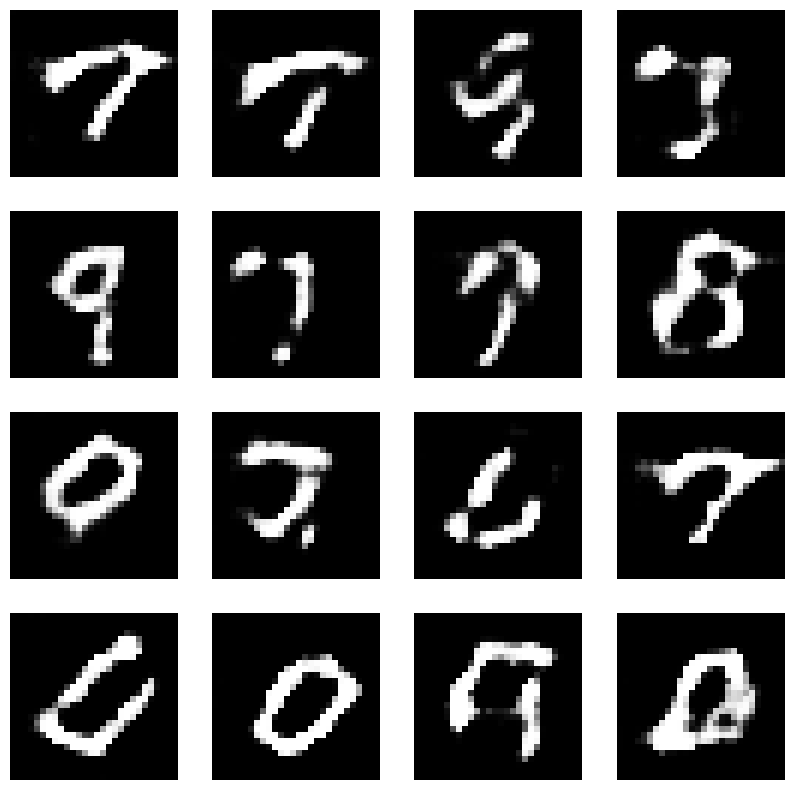

Epoch 60 complete


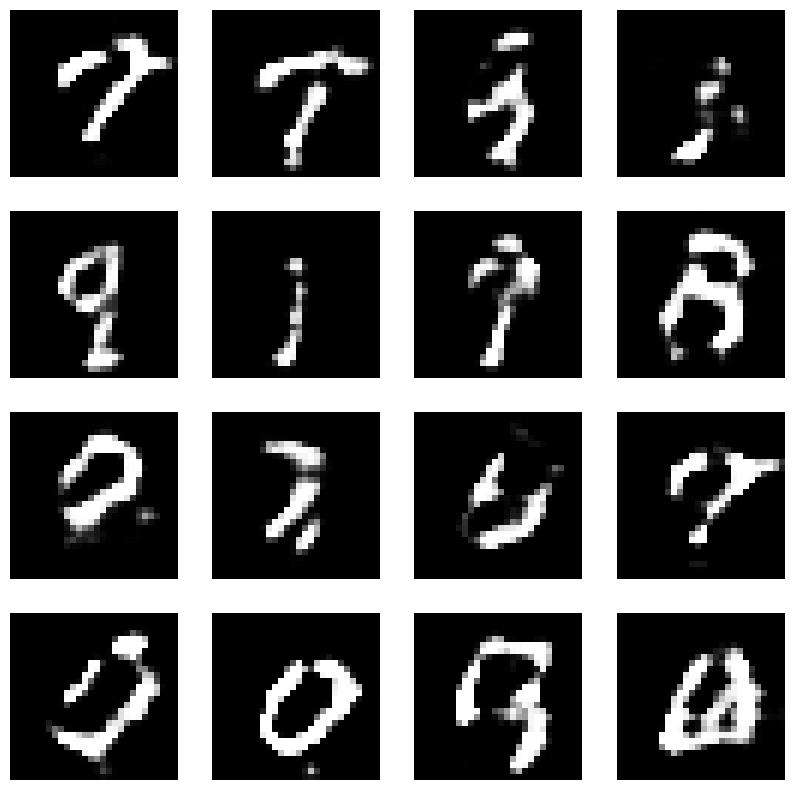

Epoch 61 complete


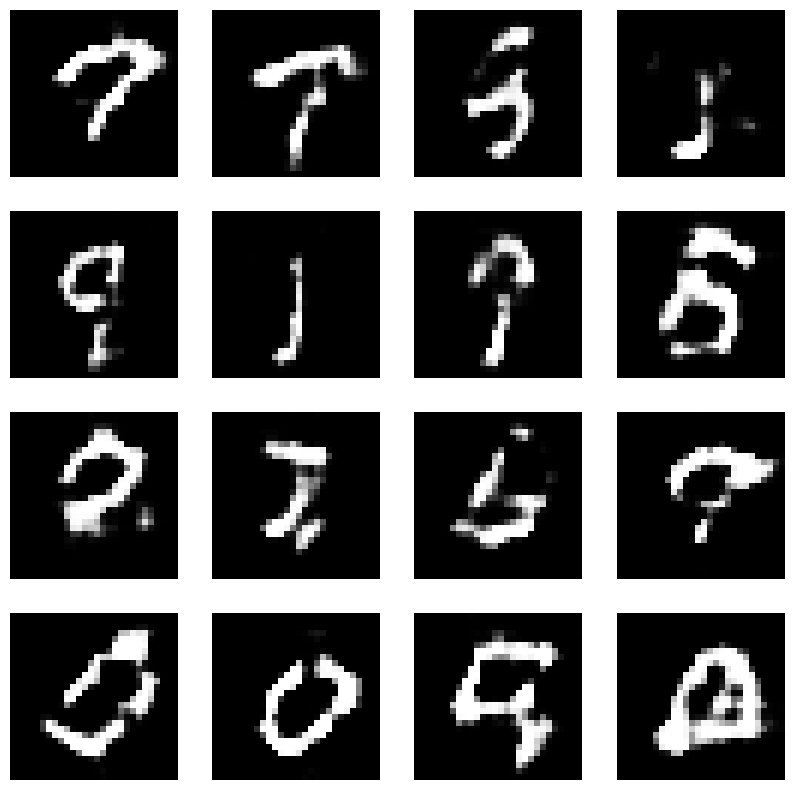

Epoch 62 complete


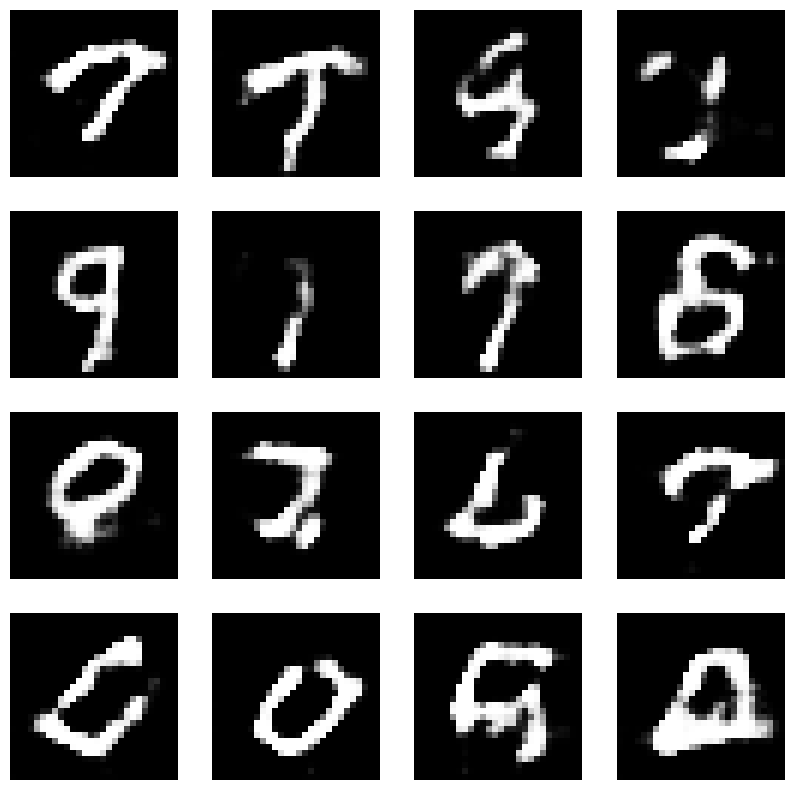

Epoch 63 complete


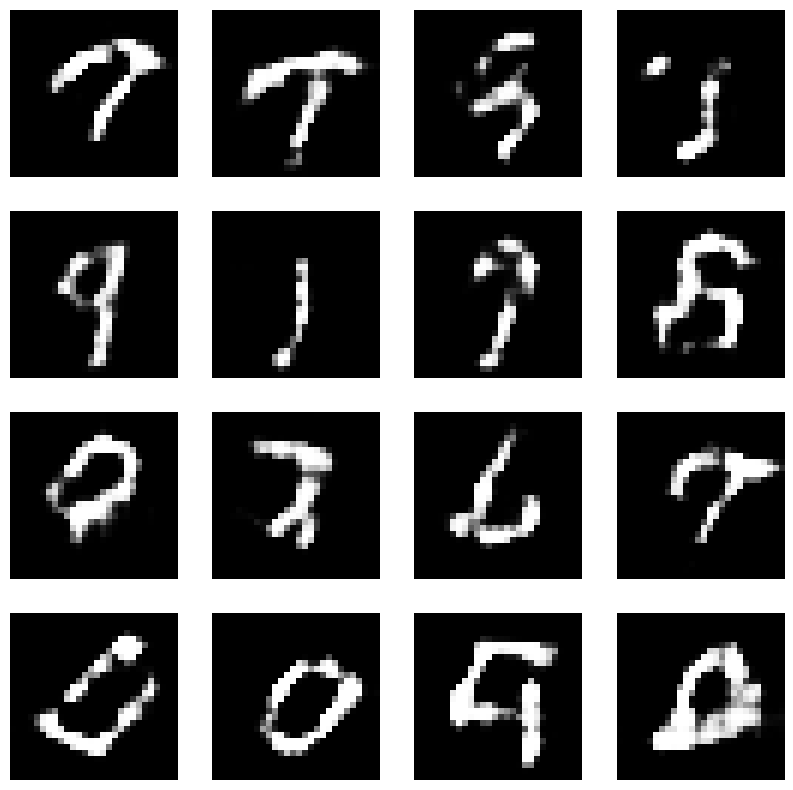

Epoch 64 complete


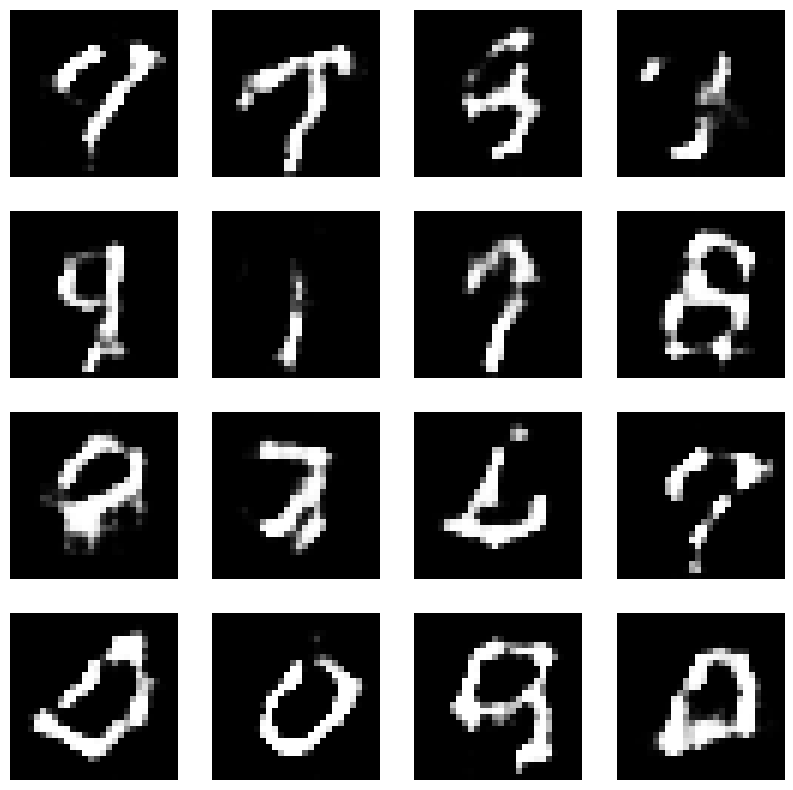

Epoch 65 complete


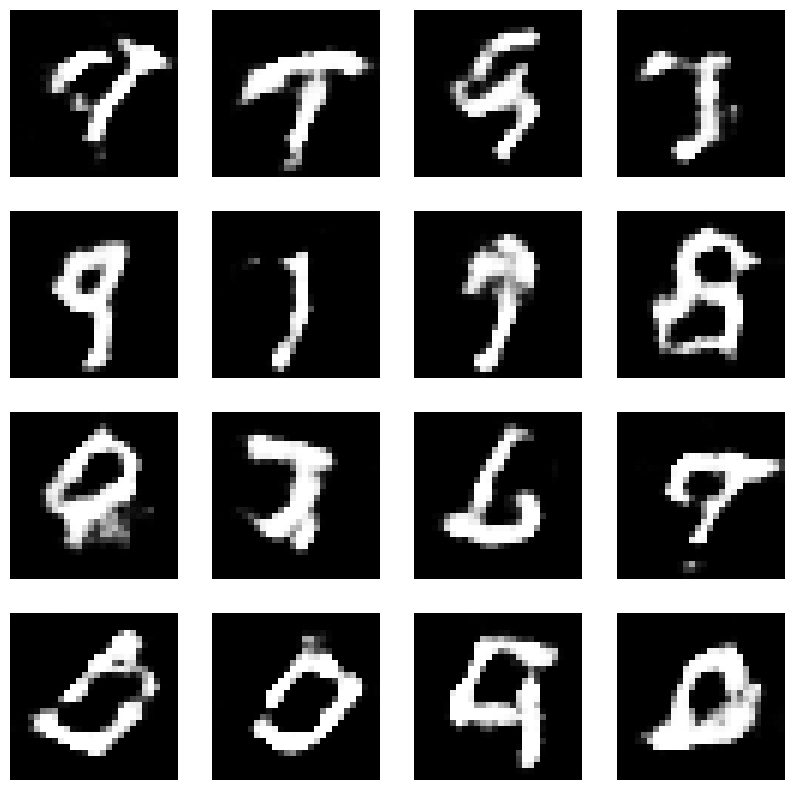

Epoch 66 complete


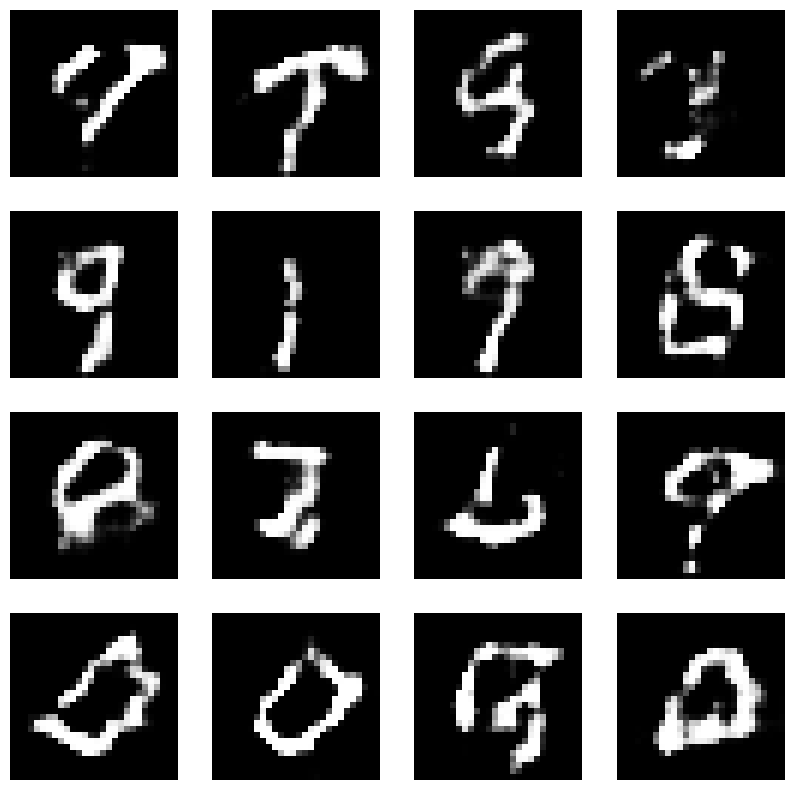

Epoch 67 complete


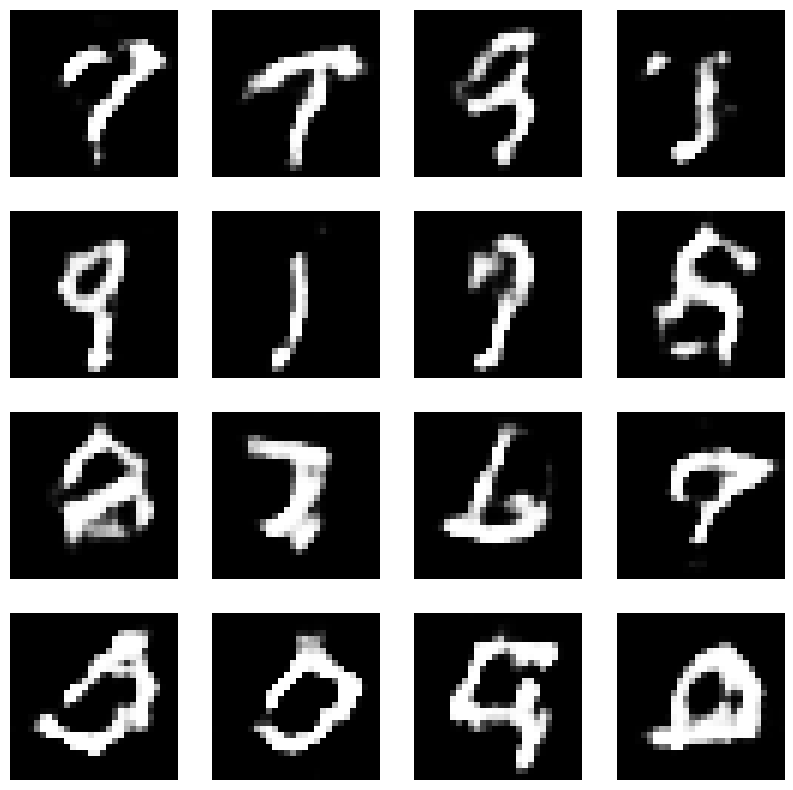

Epoch 68 complete


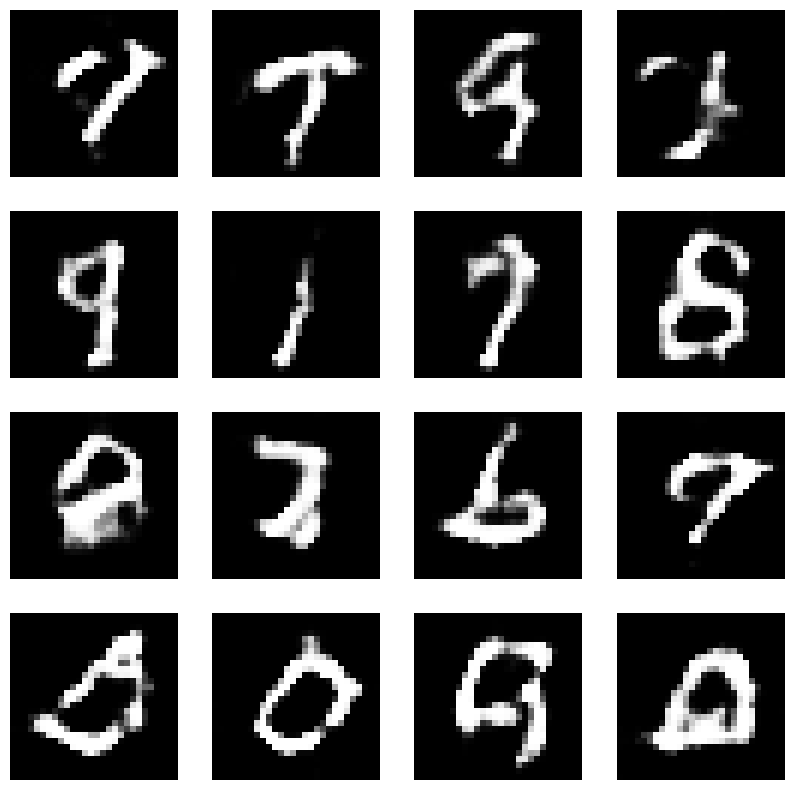

Epoch 69 complete


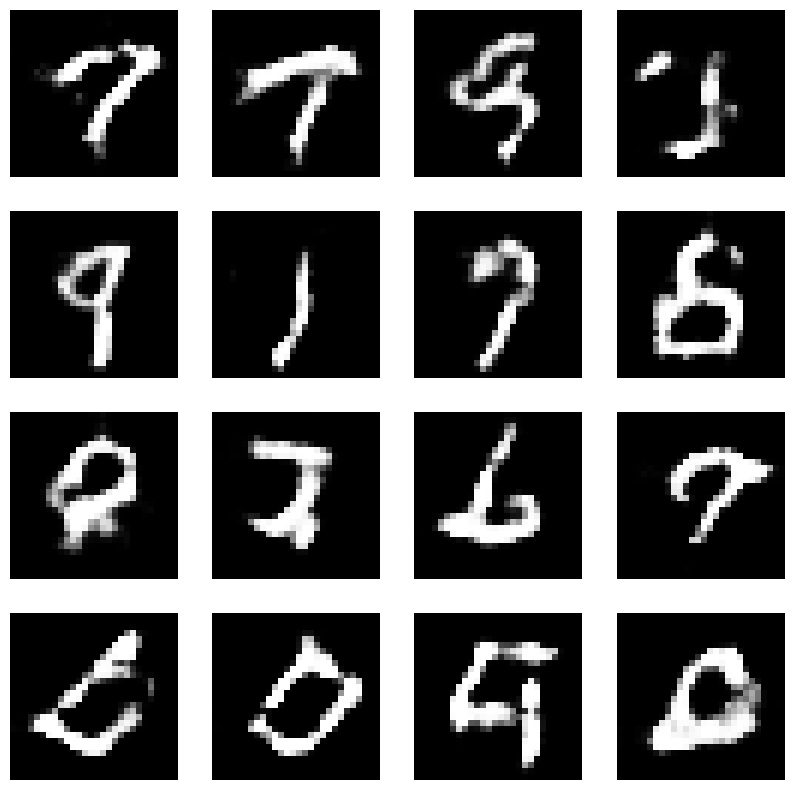

Epoch 70 complete


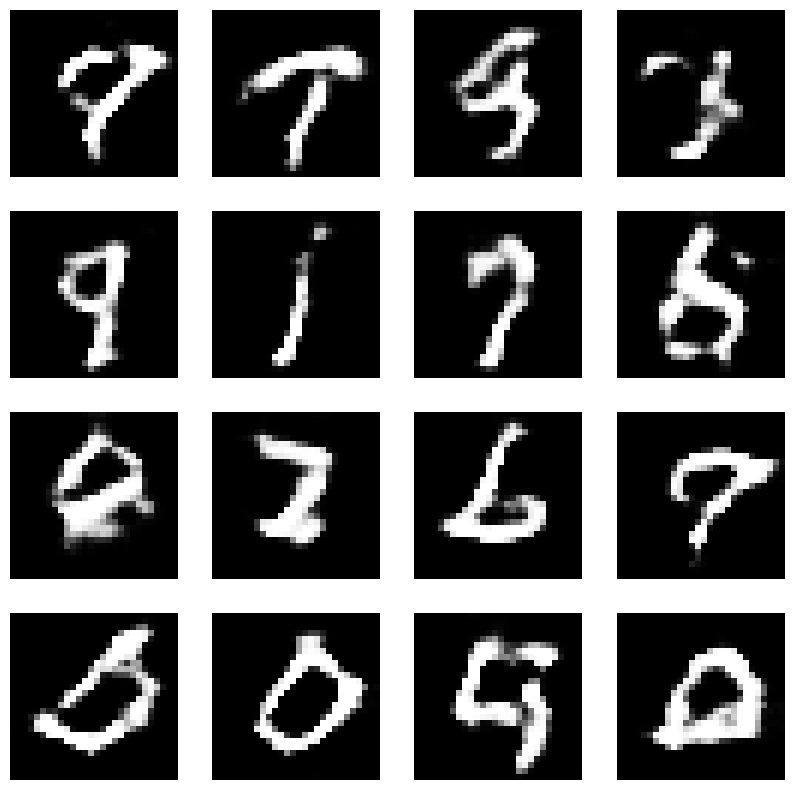

Epoch 71 complete


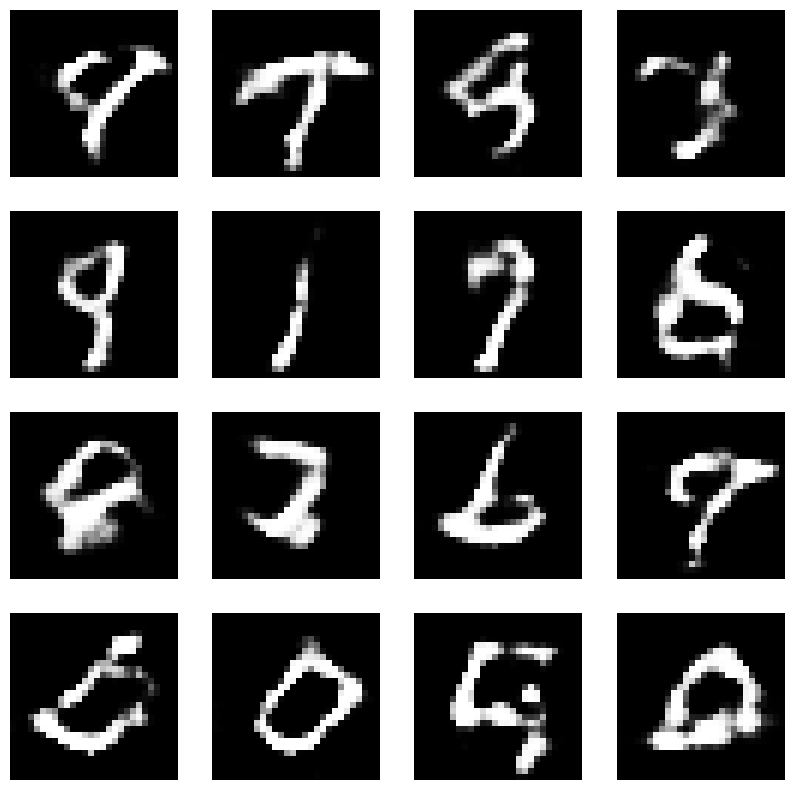

Epoch 72 complete


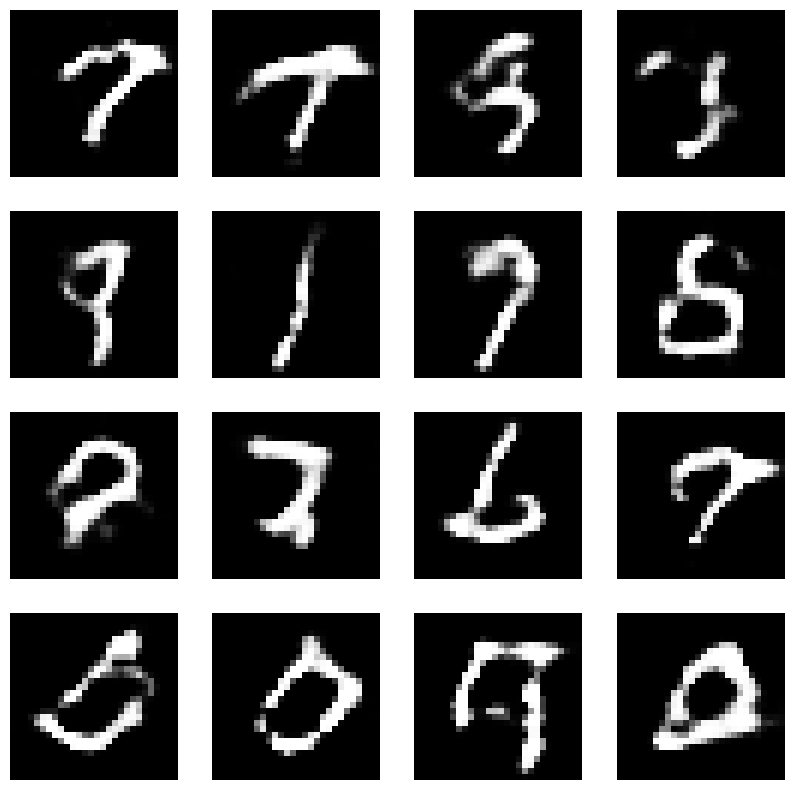

Epoch 73 complete


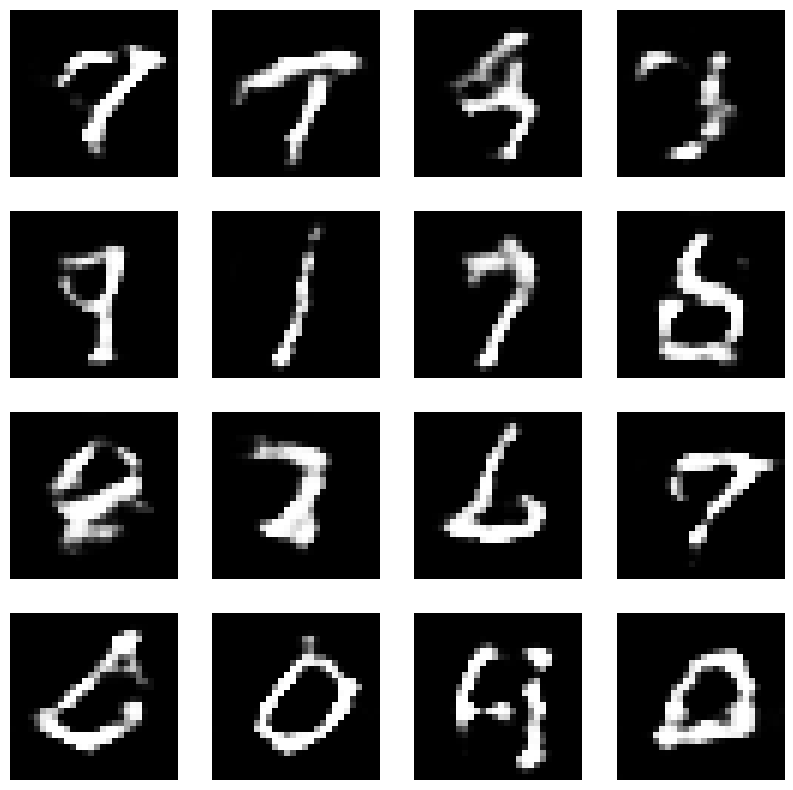

Epoch 74 complete


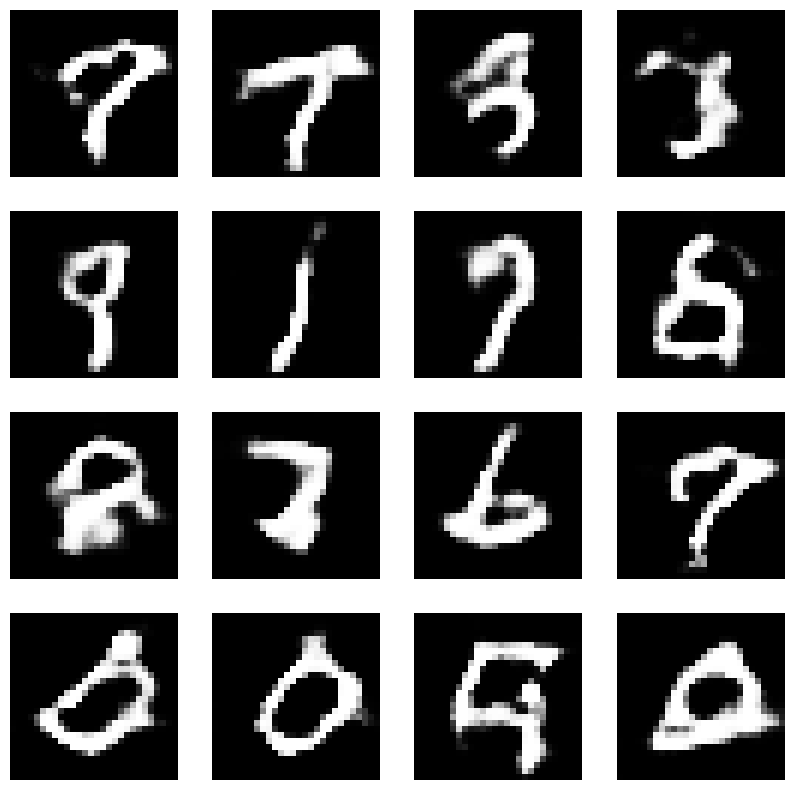

Epoch 75 complete


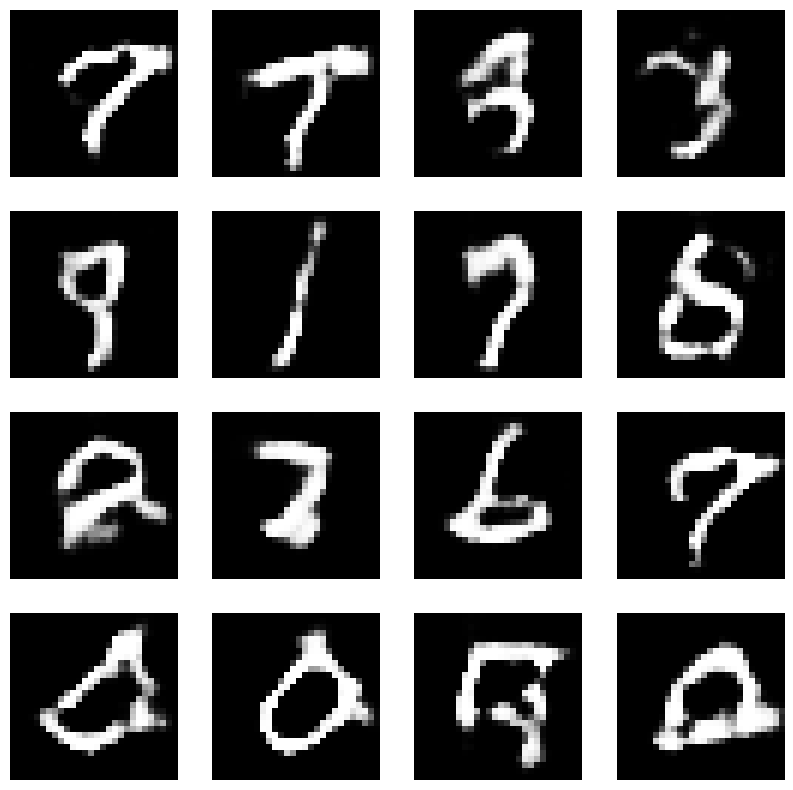

Epoch 76 complete


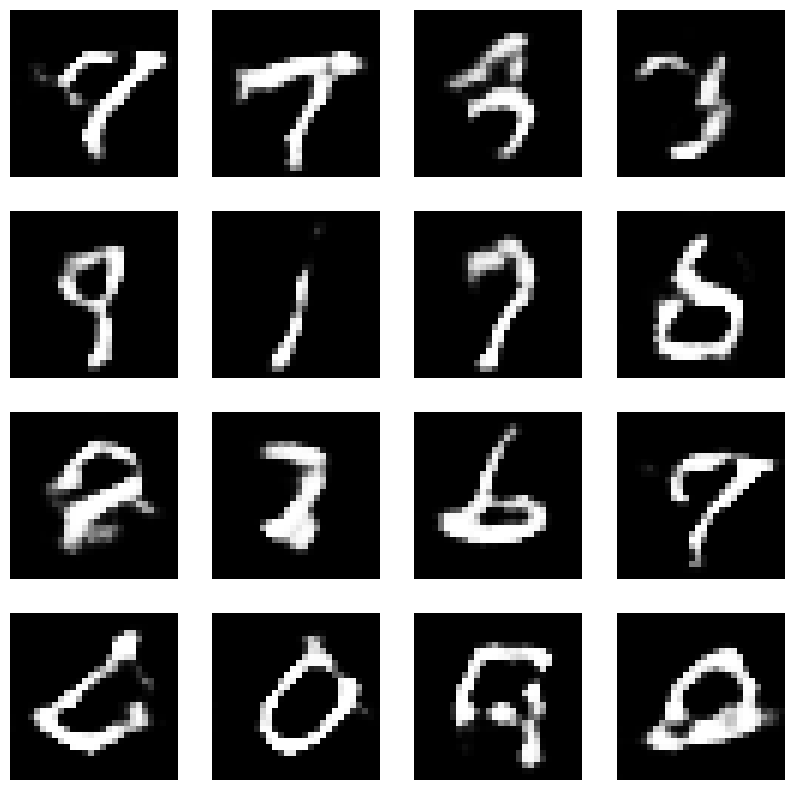

Epoch 77 complete


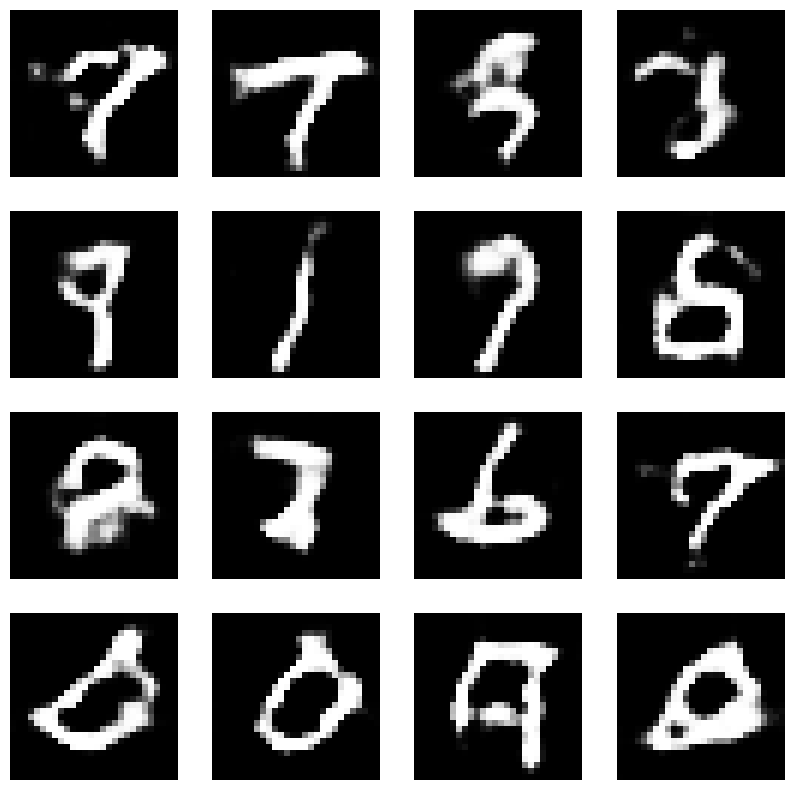

Epoch 78 complete


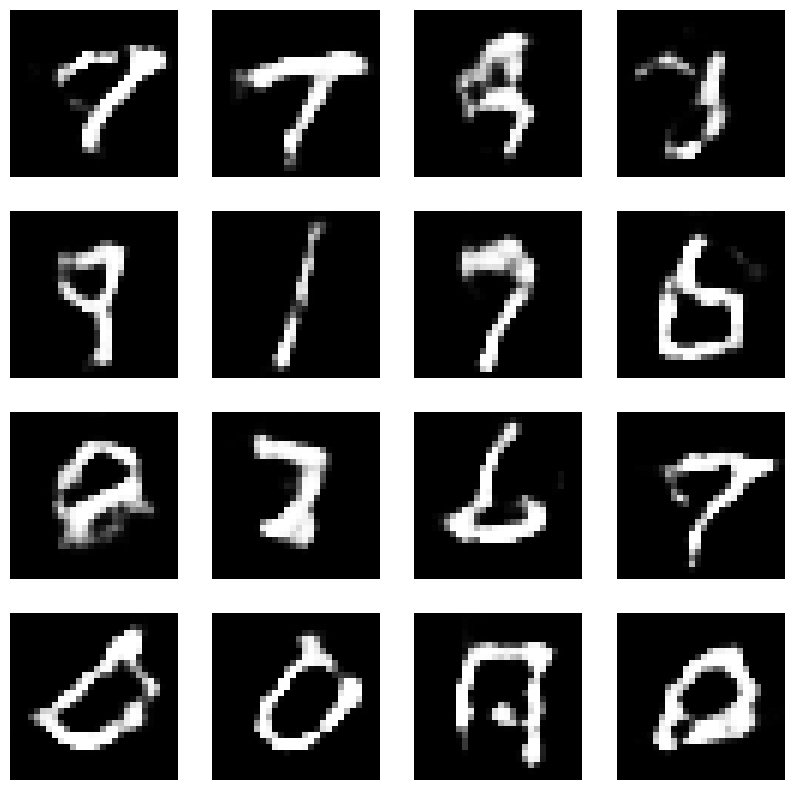

Epoch 79 complete


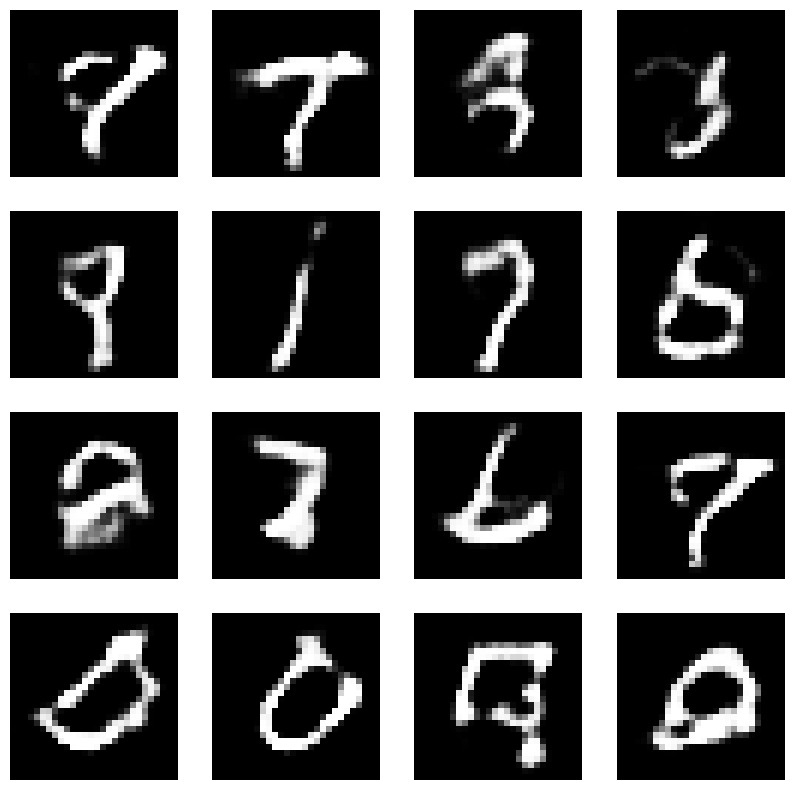

Epoch 80 complete


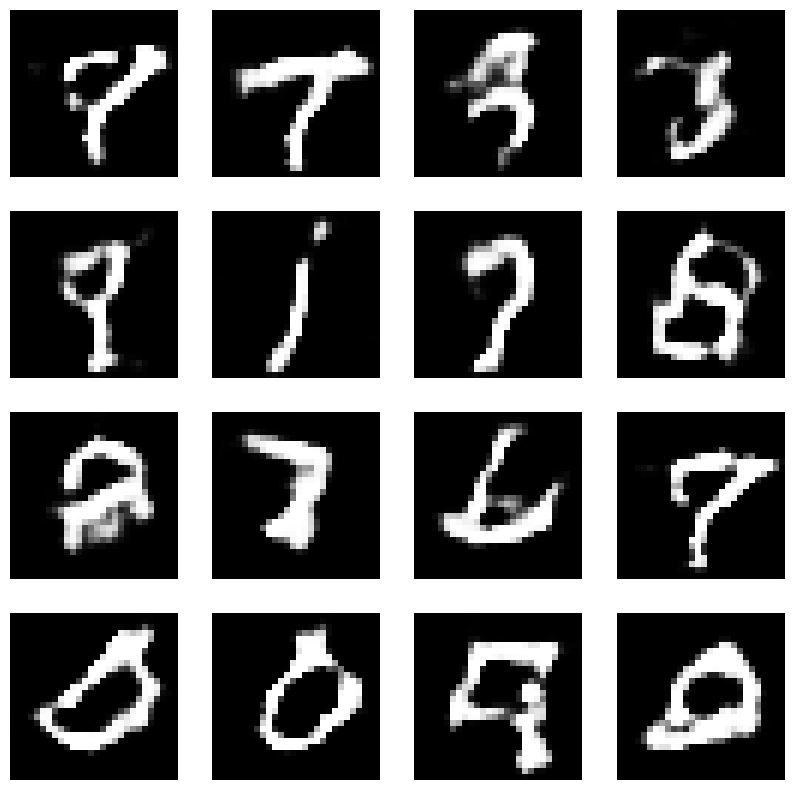

Epoch 81 complete


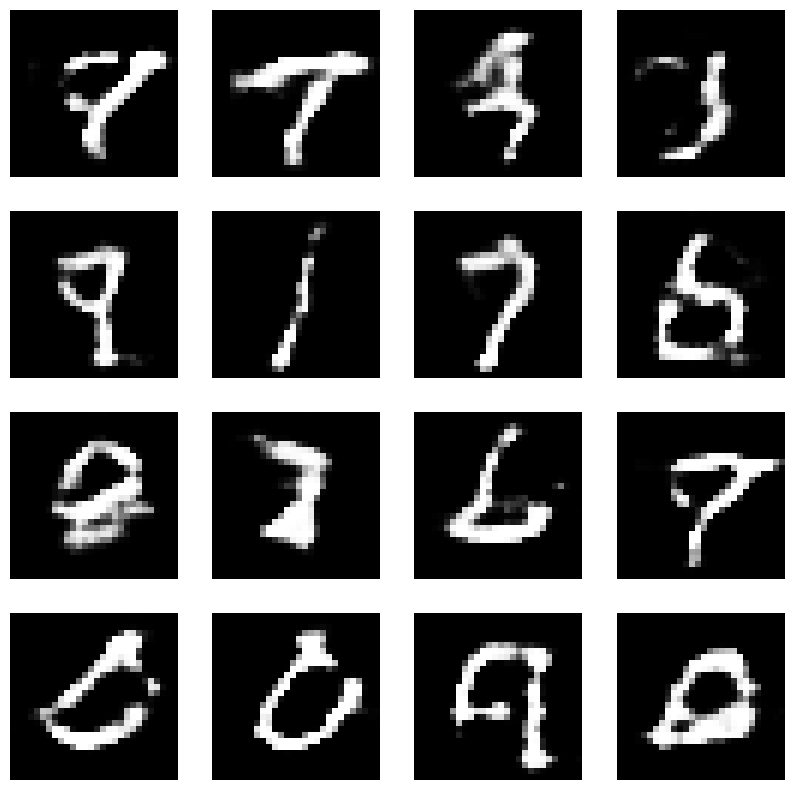

Epoch 82 complete


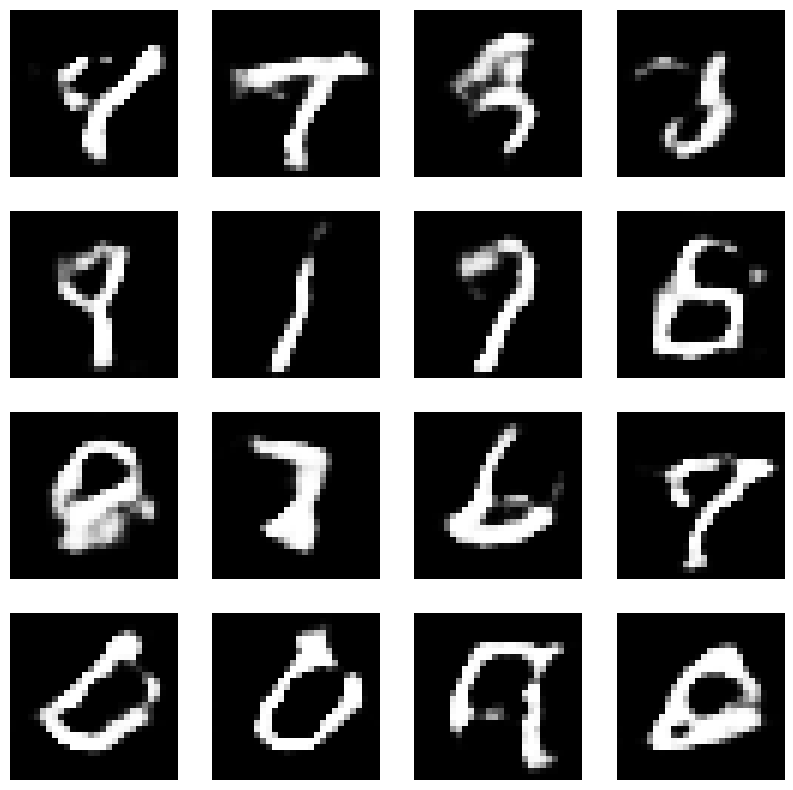

Epoch 83 complete


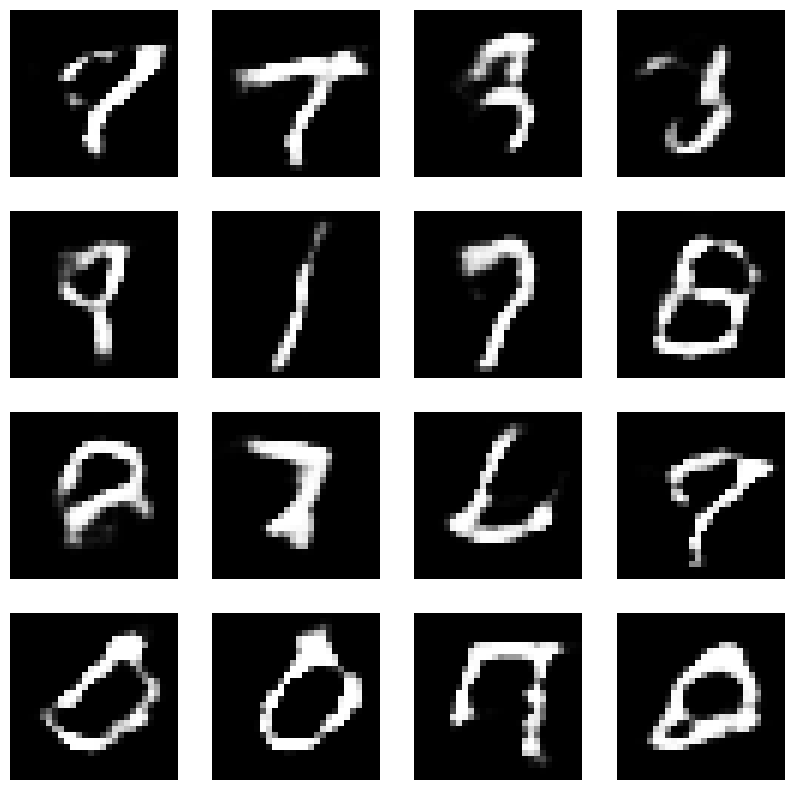

Epoch 84 complete


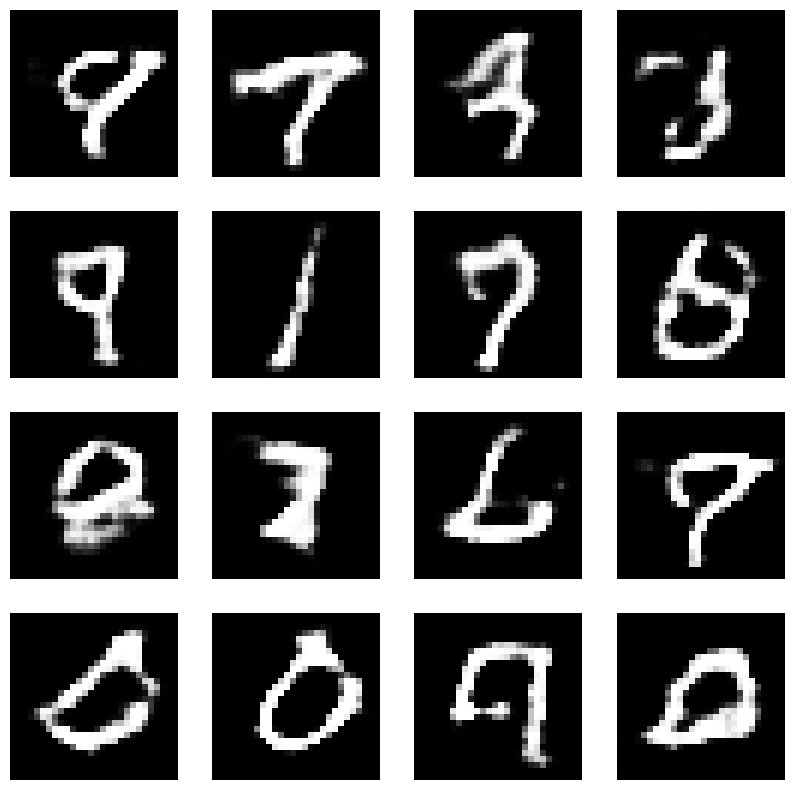

Epoch 85 complete


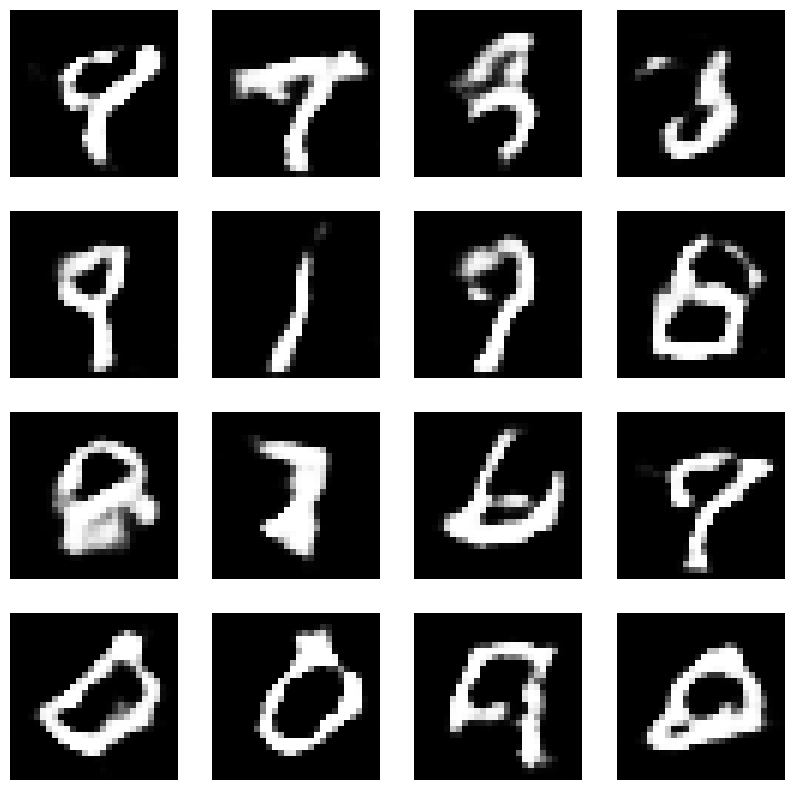

Epoch 86 complete


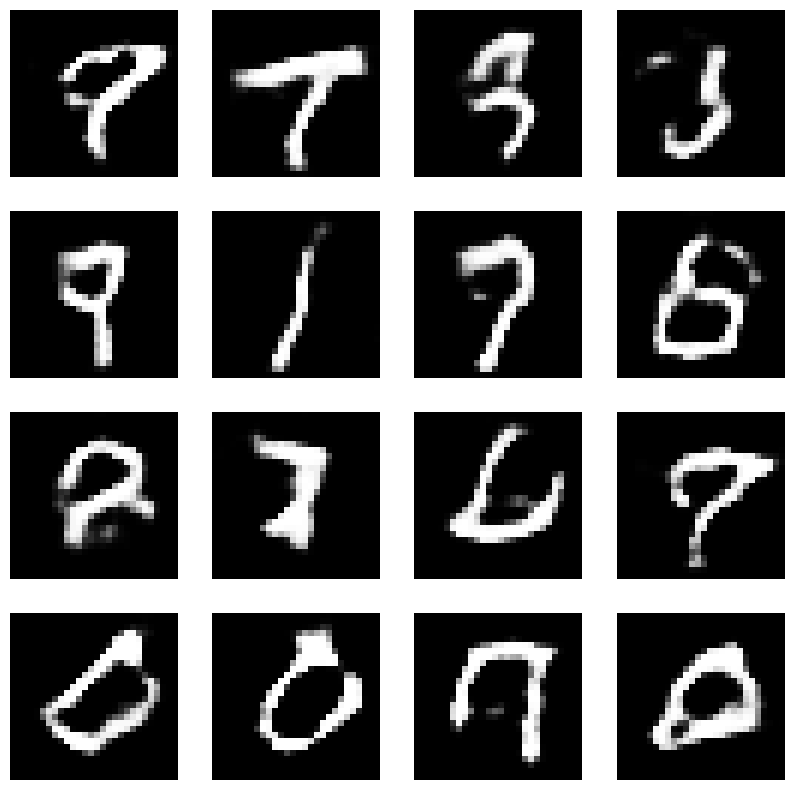

Epoch 87 complete


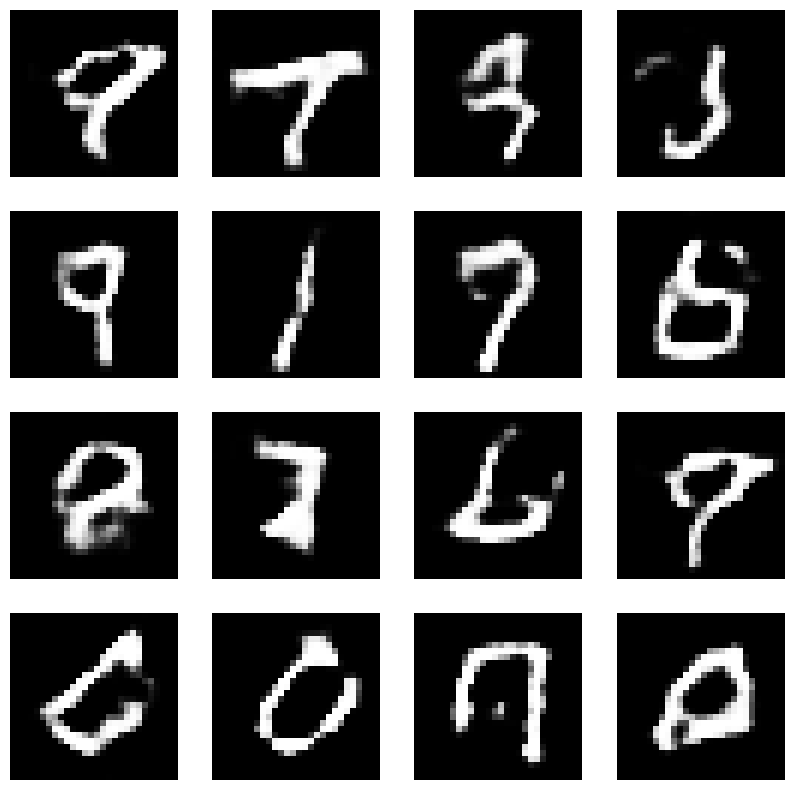

Epoch 88 complete


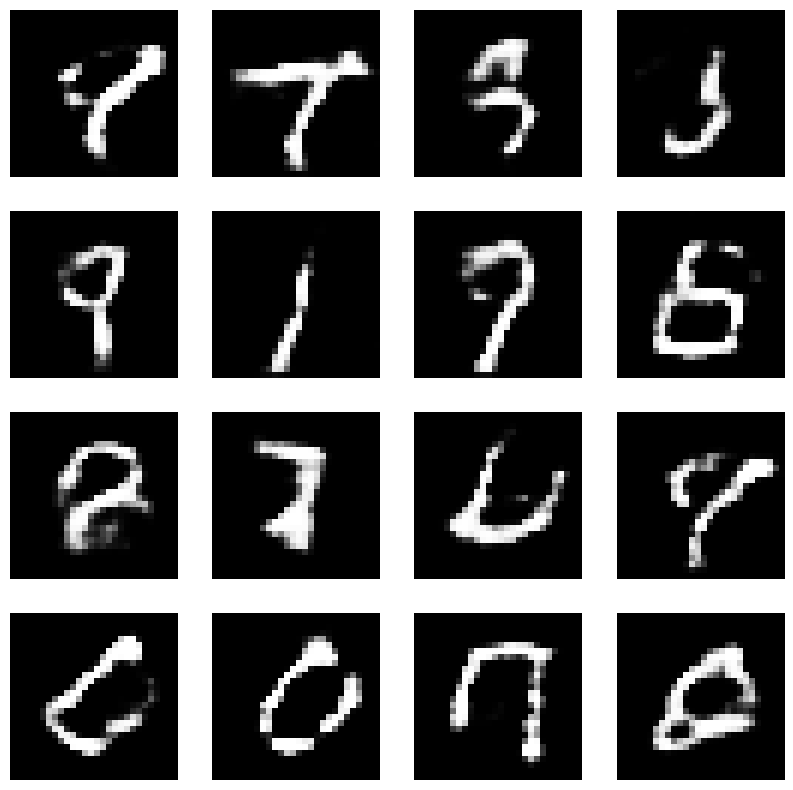

Epoch 89 complete


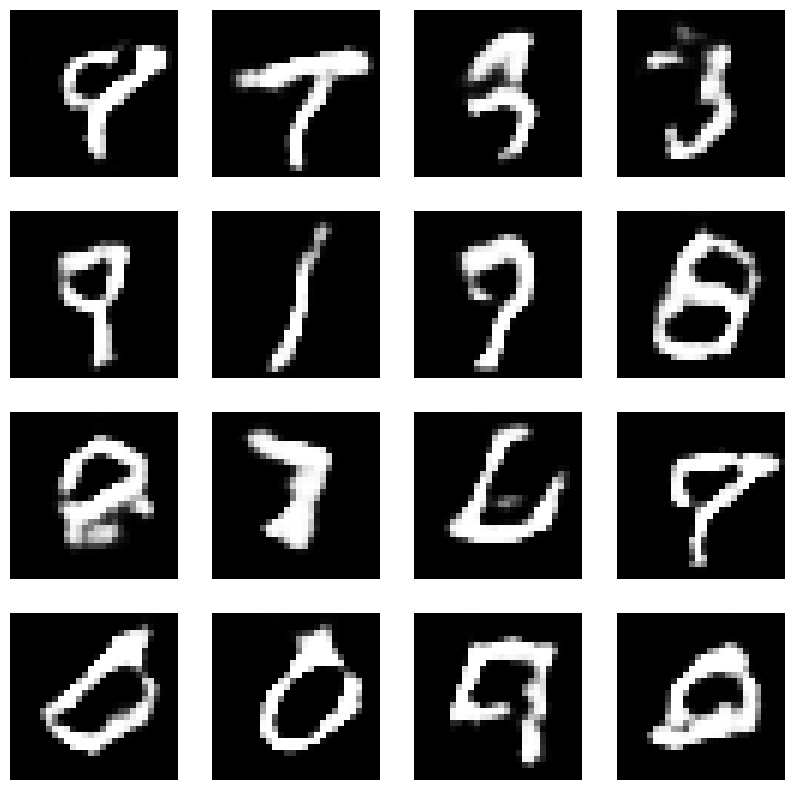

Epoch 90 complete


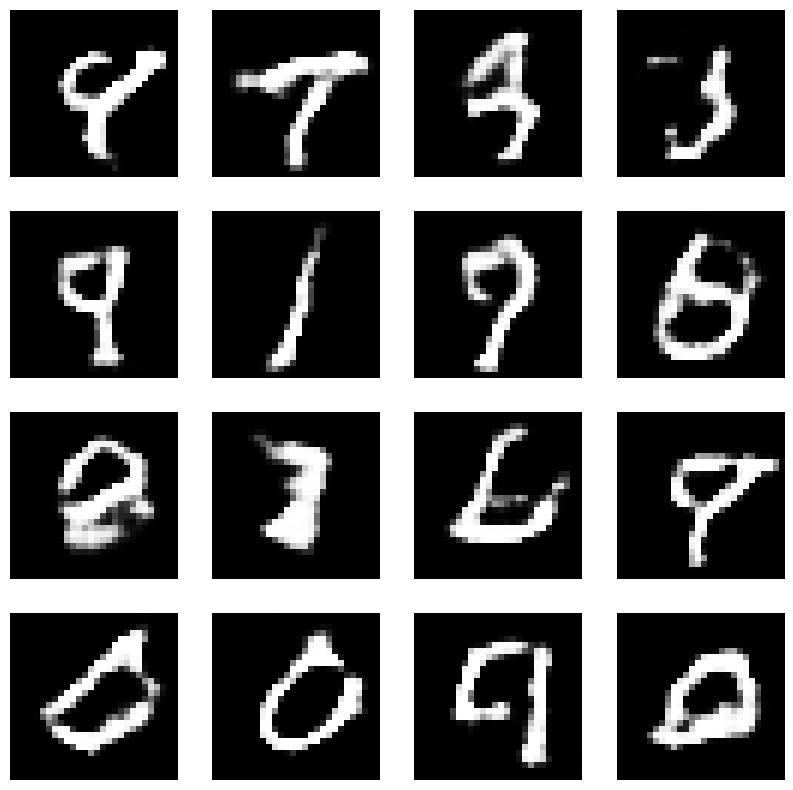

Epoch 91 complete


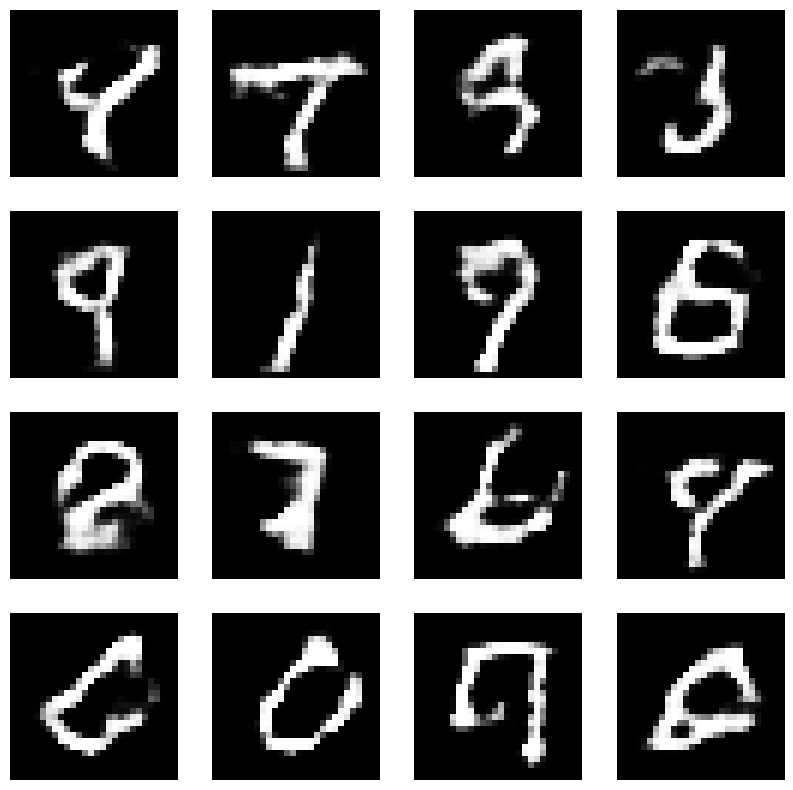

Epoch 92 complete


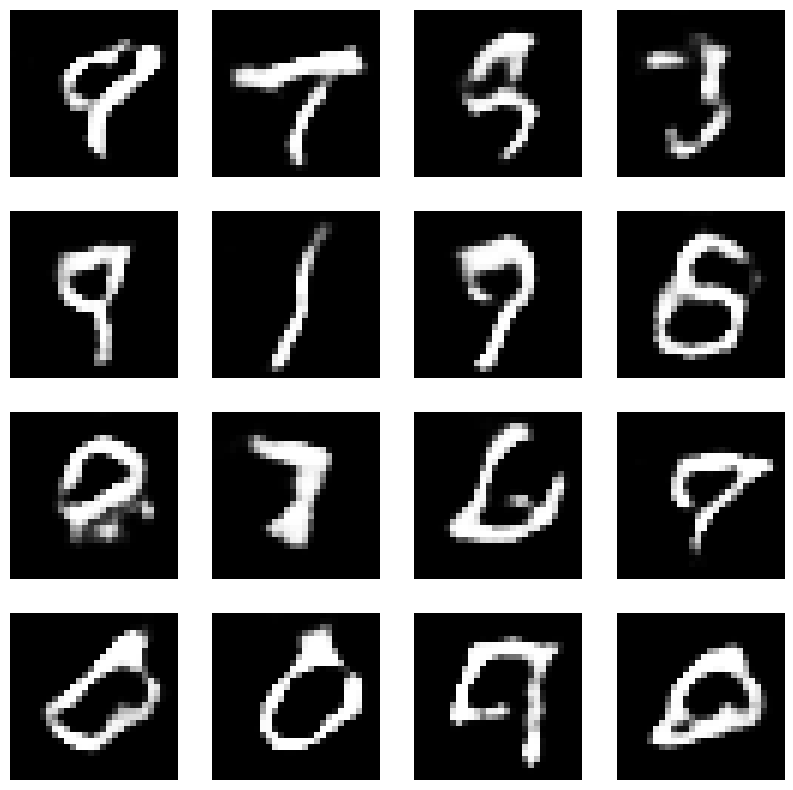

Epoch 93 complete


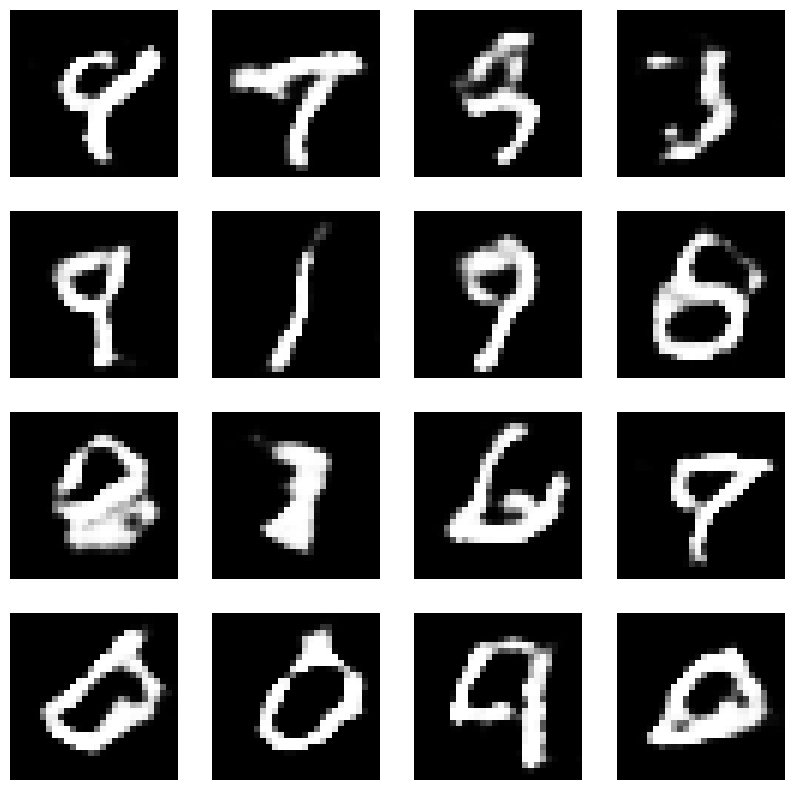

Epoch 94 complete


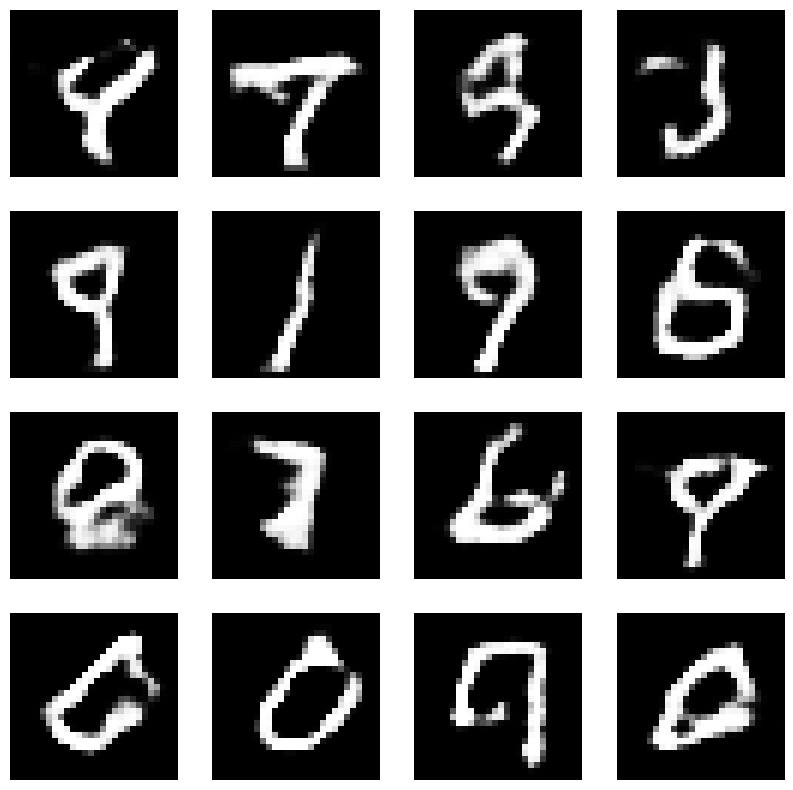

Epoch 95 complete


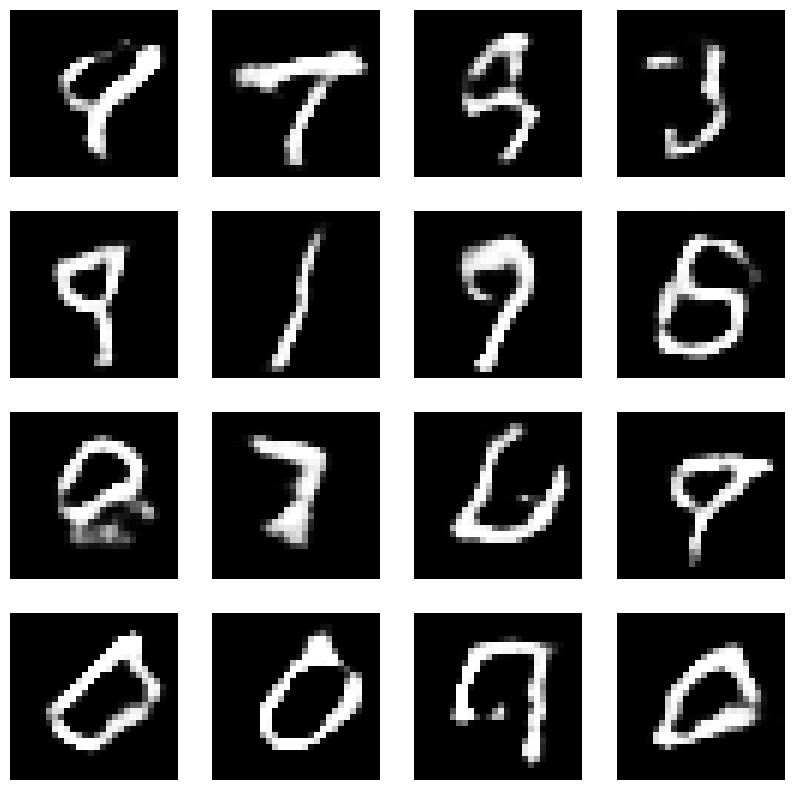

Epoch 96 complete


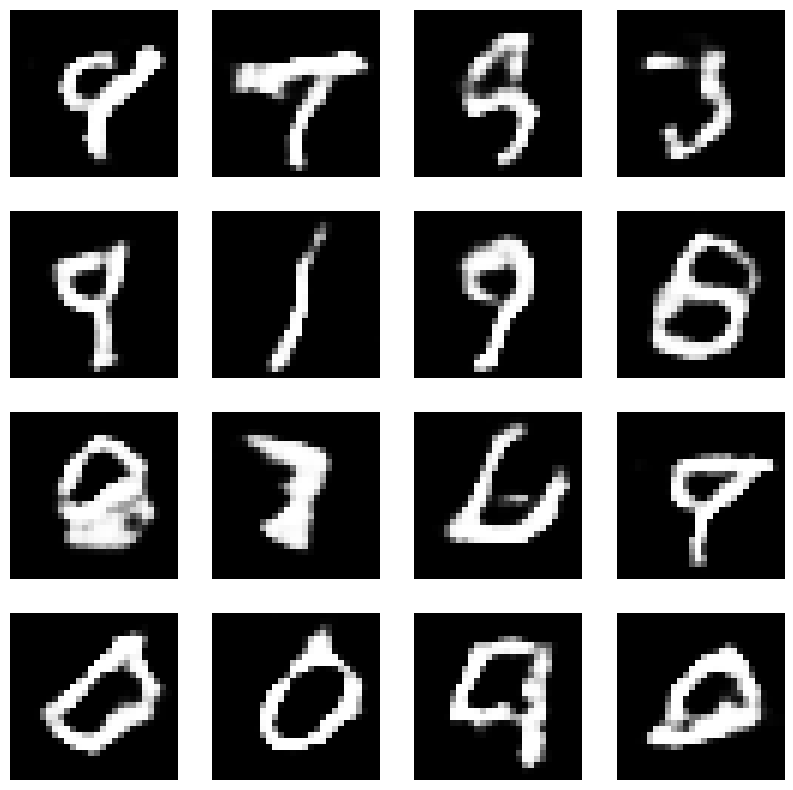

Epoch 97 complete


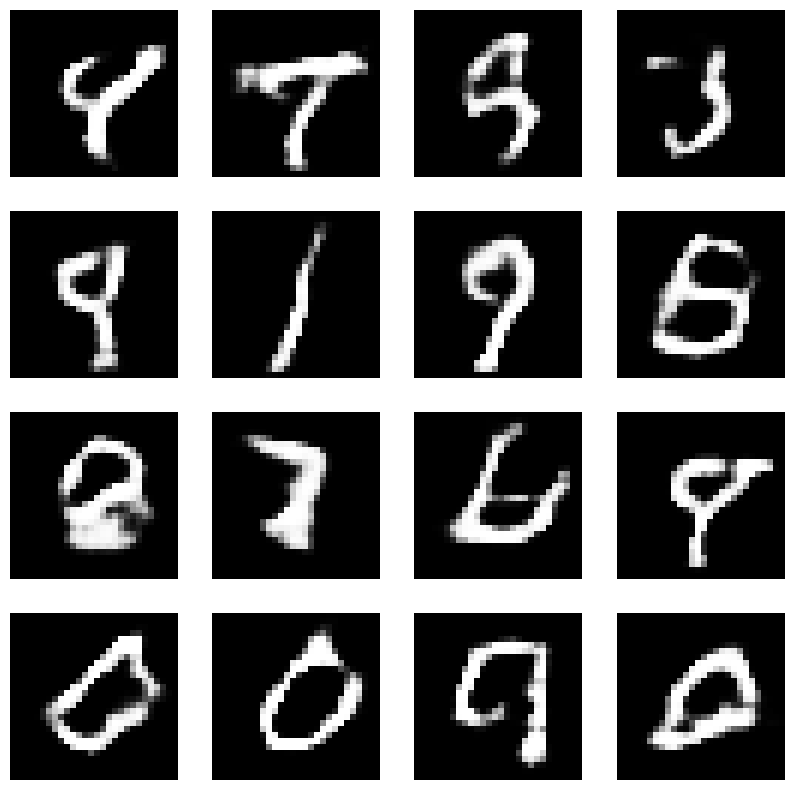

Epoch 98 complete


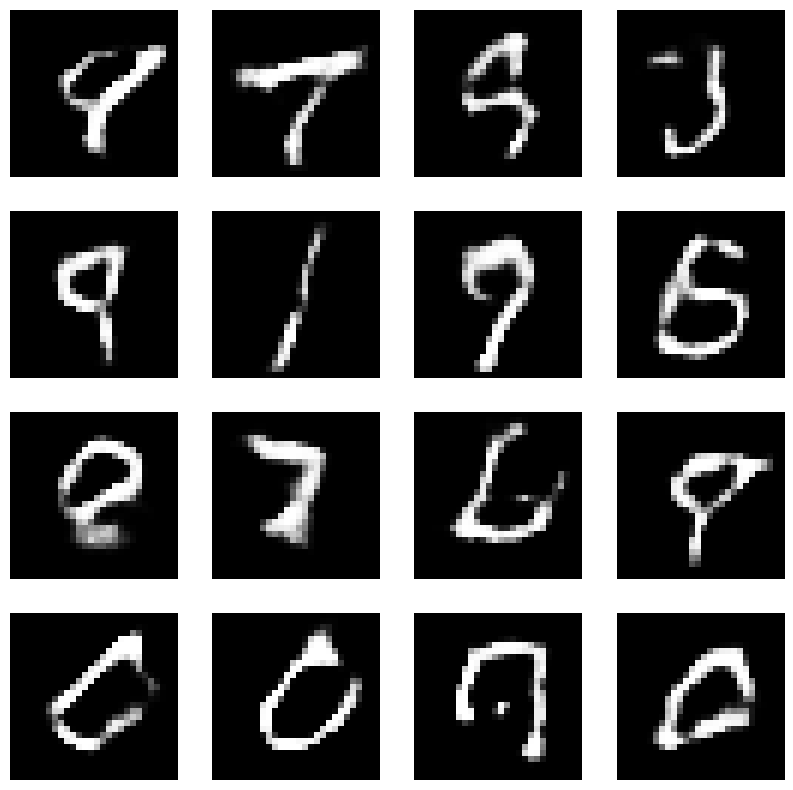

Epoch 99 complete


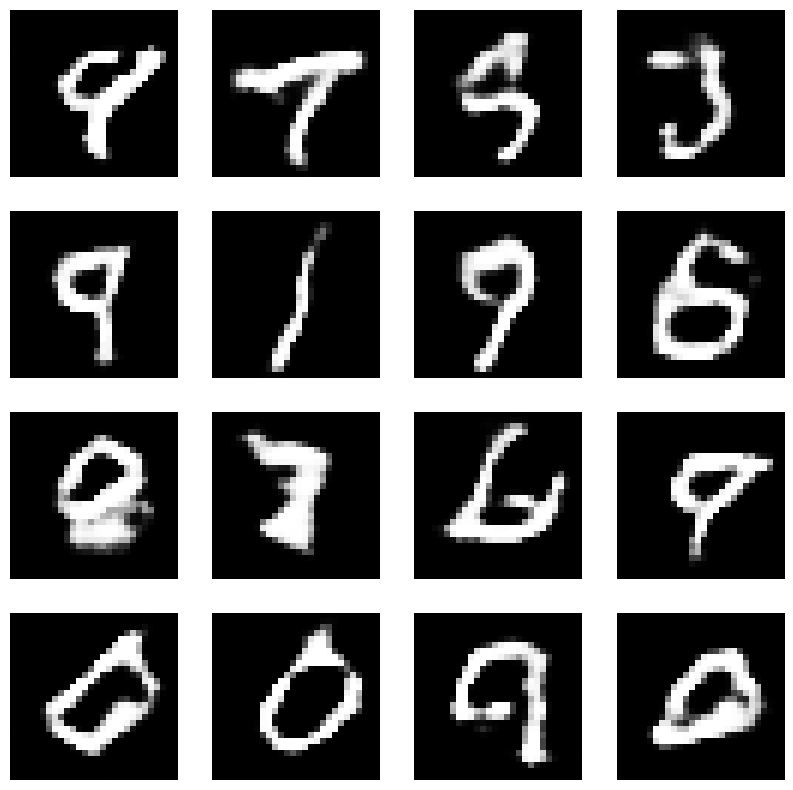

Epoch 100 complete


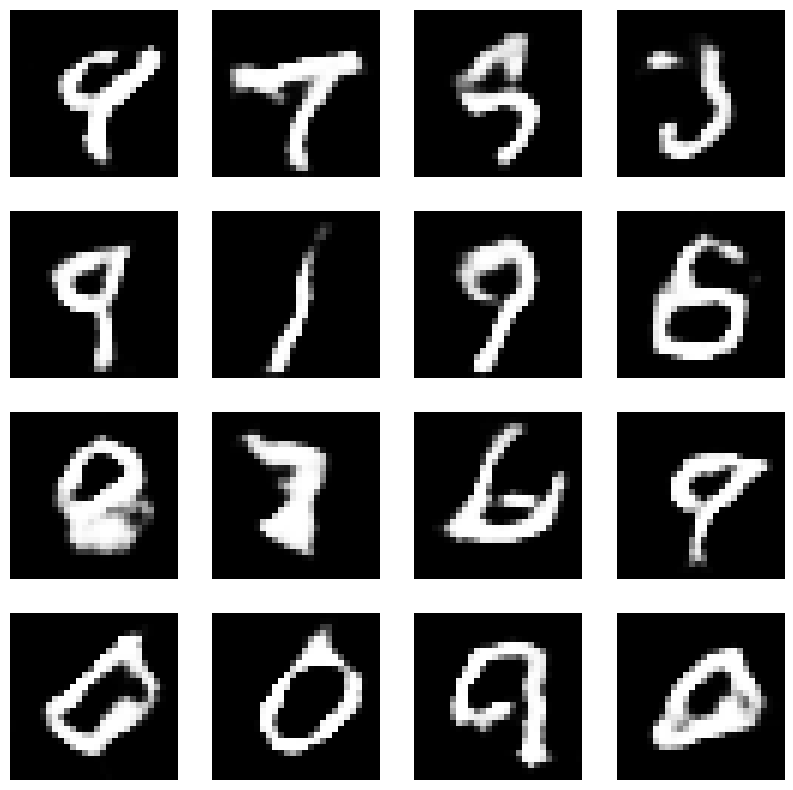

In [9]:
EPOCHS = 100
NOISE_DIM = 100
NUM_IMAGES = 16

# Fixed noise for consistent visual progress tracking
test_images = tf.random.normal([NUM_IMAGES, NOISE_DIM])

@tf.function  # Compiles to graph for speed
def train_step(image_batch):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated = generator(noise, training=True)

        real_output = discriminator(image_batch, training=True)
        fake_output = discriminator(generated,   training=True)

        gen_loss  = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_grads  = gen_tape.gradient(gen_loss,  generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(
        zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(
        zip(disc_grads, discriminator.trainable_variables))

def train_gan(dataset, epochs):
    for epoch in range(epochs):
        for batch in dataset:
            train_step(batch)

        print(f'Epoch {epoch + 1} complete')

        # Visualize 16 generated images every epoch
        generated_images = generator(test_images, training=False)
        fig = plt.figure(figsize=(10, 10))
        for i in range(generated_images.shape[0]):
            plt.subplot(4, 4, i + 1)
            plt.imshow(generated_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
            plt.axis('off')
        plt.show()

train_gan(X_train, EPOCHS)